# NHTSA Early Warning System — Complete Google Colab Implementation Guide

"Complaints Precede Recalls: An NLP-Driven Early Warning System"

- What you will build: A system that pulls 5 years of NHTSA complaint data, scores each complaint for criticality using progressively advanced NLP methods, aggregates those signals at the vehicle level, and validates the prediction against real recall records.

- What you will learn: Every NLP concept — from raw string cleaning through TF-IDF, Word2Vec, zero-shot classification, and finally LLM-based scoring — applied to a single real-world problem. Each notebook builds on the last.

## Setup / Infra
- Run this everytime setup is needed

In [238]:
!pip install -q requests pandas numpy matplotlib seaborn tqdm

In [239]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import time
import json
import os
from datetime import datetime

pd.set_option('display.max_colwidth', 100)
plt.style.use('seaborn-v0_8-whitegrid')

print("✅ Environment ready")
print(f"Pandas: {pd.__version__}, NumPy: {np.__version__}")

✅ Environment ready
Pandas: 2.2.2, NumPy: 2.0.2


## Pull Complaints from NHTSA API

NLP CONCEPT: Raw text data. Before any NLP, you need to understand
what "unstructured text" actually looks like in the wild.
Complaint text is messy, inconsistent, written by non-experts.
That messiness is exactly what NLP was invented to handle.

In [240]:
# ────────────── Cache configuration ─────────────────────────────────
# FORCE_REFETCH = True  → always call the API, overwrite existing files
# FORCE_REFETCH = False → use cached files if they exist, skip API calls
#
# Rule of thumb:
#   First run of the project          → False (nothing cached yet, will fetch)
#   Changing VEHICLES or years        → True  (cache is stale, must refetch)
#   Re-running NLP/modelling cells    → False (data hasn't changed)
#   Debugging a specific vehicle      → True  (need fresh pull)
# ────────────────────────────────────────────────────────────────────

for folder in ["data/raw", "data/processed", "data/outputs"]:
    os.makedirs(folder, exist_ok=True)
print("✅ Directories ready: data/raw/, data/processed/, data/outputs/")

FORCE_REFETCH = False   # ← flip to True only when you need fresh API data

def cache_or_fetch(filepath: str) -> bool:
    if FORCE_REFETCH:
        print(f"  ⚡ FORCE_REFETCH=True → fetching fresh: {filepath}")
        return True
    if os.path.exists(filepath) and os.path.getsize(filepath) > 100:
        print(f"  ✅ Cache hit → loading from disk: {filepath}")
        return False
    print(f"  🌐 No cache found → fetching from API: {filepath}")
    return True

print(f"FORCE_REFETCH = {FORCE_REFETCH}")

✅ Directories ready: data/raw/, data/processed/, data/outputs/
FORCE_REFETCH = False


In [241]:
# Build VEHICLES list dynamically from NHTSA API
# No hardcoded makes or models — everything comes from what the API returns
# for complaint data (issueType="c") in your target years.
# ───────────────────────────────────────────────────────────────────

YEARS_TO_TARGET = [2016, 2017, 2018, 2019, 2020]
DELAY           = 0.4   # seconds between calls — be polite to the API

# ── STEP 1: Fetch all makes that have complaint data per year ────────

def fetch_makes_for_year(year: int) -> list[str]:
    """
    Returns every make NHTSA has complaint records for in a given year.
    issueType='c' filters to complaints only (not recalls, investigations).
    """
    url    = "https://api.nhtsa.gov/products/vehicle/makes"
    params = {"modelYear": year, "issueType": "c"}
    try:
        r = requests.get(url, params=params, timeout=15)
        r.raise_for_status()
        return [m.get("make", "") for m in r.json().get("results", []) if m.get("make")]
    except Exception as e:
        print(f"  ⚠ Makes fetch failed for {year}: {e}")
        return []

print("Step 1 — Fetching all makes with complaint data per year...")

MAKES_CACHE = "data/raw/makes_by_year.json"

if not cache_or_fetch(MAKES_CACHE):
    with open(MAKES_CACHE) as f:
        makes_by_year = json.load(f)
    makes_by_year = {int(k): v for k, v in makes_by_year.items()}
    print(f"  Loaded {sum(len(v) for v in makes_by_year.values())} makes from cache")
else:
    makes_by_year: dict[int, list[str]] = {}
    for year in YEARS_TO_TARGET:
        makes = fetch_makes_for_year(year)
        makes_by_year[year] = makes
        print(f"  {year}: {len(makes)} makes found")
        time.sleep(DELAY)
    with open(MAKES_CACHE, "w") as f:
        json.dump(makes_by_year, f)
    print(f"  ✅ Saved → {MAKES_CACHE}")

makes_all_years = [
    make for make in set(m for makes in makes_by_year.values() for m in makes)
    if all(make in makes_by_year[y] for y in YEARS_TO_TARGET)
]
makes_all_years.sort()
print(f"\nMakes present in ALL {len(YEARS_TO_TARGET)} target years: {len(makes_all_years)}")


Step 1 — Fetching all makes with complaint data per year...
  ✅ Cache hit → loading from disk: data/raw/makes_by_year.json
  Loaded 722 makes from cache

Makes present in ALL 5 target years: 71


In [242]:
# For each (make, year) pair, fetch available models with complaints.
# Then keep only models that appear consistently across all years.
# ───────────────────────────────────────────────────────────────────

def fetch_models_for_make_year(make: str, year: int) -> list[str]:
    url    = "https://api.nhtsa.gov/products/vehicle/models"
    params = {"modelYear": year, "issueType": "c", "make": make}
    try:
        r = requests.get(url, params=params, timeout=15)
        r.raise_for_status()
        return [m.get("model", "") for m in r.json().get("results", []) if m.get("model")]
    except Exception as e:
        print(f"  ⚠ Models fetch failed for {make} {year}: {e}")
        return []


print("Step 2 — Fetching models per make per year...")
print("(This takes a few minutes — one API call per make × year)")
print()

# models_registry[make][year] = [list of models with complaint data]
MODELS_CACHE = "data/raw/models_registry.json"

if not cache_or_fetch(MODELS_CACHE):
    import json
    with open(MODELS_CACHE) as f:
        models_registry = json.load(f)
    # Restore int year keys
    models_registry = {
        make: {int(y): models for y, models in year_dict.items()}
        for make, year_dict in models_registry.items()
    }
    print(f"  Loaded models for {len(models_registry)} makes from cache")

else:
    models_registry = {}
    for make in tqdm(makes_all_years, desc="Fetching models"):
        models_registry[make] = {}
        for year in YEARS_TO_TARGET:
            models = fetch_models_for_make_year(make, year)
            models_registry[make][year] = models
            time.sleep(DELAY)

    import json
    with open(MODELS_CACHE, "w") as f:
        json.dump(models_registry, f)
    print(f"  ✅ Saved → {MODELS_CACHE}")

Step 2 — Fetching models per make per year...
(This takes a few minutes — one API call per make × year)

  ✅ Cache hit → loading from disk: data/raw/models_registry.json
  Loaded models for 71 makes from cache


In [243]:
# ──— Build the consistent make-model catalogue ────────────
# A (make, model) pair is "consistent" if the model appears in the
# complaint database for EVERY target year.
# Inconsistent pairs create gaps in temporal features.
# ───────────────────────────────────────────────────────────────────

catalogue_rows = []

for make, year_models in models_registry.items():
    # Collect the union of all models for this make
    all_models_for_make = set(
        model
        for year_model_list in year_models.values()
        for model in year_model_list
    )
    for model in all_models_for_make:
        years_present = [y for y in YEARS_TO_TARGET if model in year_models.get(y, [])]
        catalogue_rows.append({
            "make":           make,
            "model":          model,
            "years_present":  len(years_present),
            "years_list":     years_present,
            "fully_covered":  len(years_present) == len(YEARS_TO_TARGET),
        })

df_catalogue = pd.DataFrame(catalogue_rows).sort_values(
    ["make", "years_present"], ascending=[True, False]
)

print("Full catalogue shape:", df_catalogue.shape)
print(f"\nFully covered (present all {len(YEARS_TO_TARGET)} years): "
      f"{df_catalogue['fully_covered'].sum()} make-model pairs")
print(f"Partially covered: {(~df_catalogue['fully_covered']).sum()} pairs")

# Preview
print("\nSample of fully-covered pairs:")
print(
    df_catalogue[df_catalogue["fully_covered"]]
    [["make", "model", "years_present"]]
    .head(20)
    .to_string(index=False)
)

Full catalogue shape: (1504, 5)

Fully covered (present all 5 years): 251 make-model pairs
Partially covered: 1253 pairs

Sample of fully-covered pairs:
 make    model  years_present
ACURA      MDX              5
ACURA      TLX              5
ACURA      RDX              5
ACURA      ILX              5
 AUDI       A3              5
 AUDI       A6              5
 AUDI       S3              5
 AUDI       A4              5
 AUDI       A7              5
 AUDI       Q3              5
 AUDI       Q7              5
 AUDI       A5              5
 AUDI       Q5              5
 AUDI      SQ5              5
  BMW 3 SERIES              5
  BMW       X3              5
  BMW       X4              5
  BMW 4 SERIES              5
  BMW       X5              5
  BMW 2 SERIES              5


In [244]:
# ── CELL 1.4 — Intelligent filtering: tractable but representative ───
#
# The fully-covered catalogue may still contain hundreds of pairs —
# pulling complaints for all of them would take hours.
# Apply a two-pass filter:
#
#   PASS 1 (volume proxy): Quick complaint-count fetch for each pair.
#           Keep pairs with >= MIN_COMPLAINTS complaints in ANY one year.
#           Low-count pairs add noise without predictive signal.
#
#   PASS 2 (recall diversity): Sample across makes — ensure at least
#           one model per major make so the final dataset spans the
#           range of recall histories (high-risk vs low-risk vehicles).
#
# Result: a VEHICLES list of 15–30 pairs — enough signal, sane runtime.
# ───────────────────────────────────────────────────────────────────

MIN_COMPLAINTS     = 10    # Minimum complaints in any single year to include
MAX_MODELS_PER_MAKE = 2    # Cap per make to avoid Toyota/Ford dominating

def fetch_complaint_count(make: str, model: str, year: int) -> int:
    """Quick count — just returns length of results, not full records."""
    url    = "https://api.nhtsa.gov/complaints/complaintsByVehicle"
    params = {"make": make, "model": model, "modelYear": year}
    try:
        r = requests.get(url, params=params, timeout=15)
        r.raise_for_status()
        return len(r.json().get("results", []))
    except Exception:
        return 0


# Work from the fully-covered subset only
df_covered = df_catalogue[df_catalogue["fully_covered"]].copy()

# Sample the middle year as the volume proxy
# Middle year (e.g. 2018) avoids edge effects at start/end of window
probe_year = YEARS_TO_TARGET[len(YEARS_TO_TARGET) // 2]
PROBE_CACHE = f"data/raw/complaint_probe_{probe_year}.csv"

print(f"Probing complaint volume for {len(df_covered)} fully-covered pairs...")
print(f"(Sampling year {probe_year} as proxy)")

if not cache_or_fetch(PROBE_CACHE):
    # FIX: load only the probe column from cache and merge it in —
    # avoids overwriting df_covered with a file that may be missing
    # columns built in Cell 1.3 (years_list, fully_covered, etc.)
    probe_cached = pd.read_csv(PROBE_CACHE)[["make", "model", f"complaints_{probe_year}"]]
    df_covered = df_covered.merge(probe_cached, on=["make", "model"], how="left")
    print(f"  Probe column merged from cache ({probe_cached[f'complaints_{probe_year}'].notna().sum()} values)")
else:
    complaint_counts = []
    for _, row in tqdm(df_covered.iterrows(), total=len(df_covered), desc="Probing"):
        count = fetch_complaint_count(row["make"], row["model"], probe_year)
        complaint_counts.append(count)
        time.sleep(DELAY)
    df_covered[f"complaints_{probe_year}"] = complaint_counts
    # Save only the columns needed for the cache (lightweight)
    df_covered[["make", "model", f"complaints_{probe_year}"]].to_csv(PROBE_CACHE, index=False)
    print(f"  ✅ Saved → {PROBE_CACHE}")

Probing complaint volume for 251 fully-covered pairs...
(Sampling year 2018 as proxy)
  ✅ Cache hit → loading from disk: data/raw/complaint_probe_2018.csv
  Probe column merged from cache (251 values)


In [245]:
# ── CELL 1.5 — Apply filters and build final VEHICLES list ──────────

# Pass 1: minimum volume filter
df_filtered = df_covered[df_covered[f"complaints_{probe_year}"] >= MIN_COMPLAINTS].copy()
df_filtered = df_filtered.sort_values(f"complaints_{probe_year}", ascending=False)

print(f"After volume filter (>= {MIN_COMPLAINTS} complaints): {len(df_filtered)} pairs")

# Pass 2: cap per make — take the top-N models by complaint volume
df_selected = (
    df_filtered
    .sort_values(["make", f"complaints_{probe_year}"], ascending=[True, False])
    .groupby("make", group_keys=False)[df_filtered.columns]   # explicit column selection keeps 'make'
    .head(MAX_MODELS_PER_MAKE)
    .reset_index(drop=True)
)

print(f"After per-make cap ({MAX_MODELS_PER_MAKE} max per make): {len(df_selected)} pairs")

# Build the VEHICLES structure expected by the rest of the pipeline
VEHICLES = [
    {
        "make":  row["make"],
        "model": row["model"],
        "years": YEARS_TO_TARGET,
    }
    for _, row in df_selected.iterrows()
]

# ── Summary table ──
print("\n" + "=" * 60)
print("FINAL VEHICLE SELECTION")
print("=" * 60)
summary_df = df_selected[["make", "model", f"complaints_{probe_year}"]].copy()
summary_df.columns = ["make", "model", f"complaints_{probe_year} (proxy)"]
print(summary_df.to_string(index=False))
print(f"\nTotal pairs selected: {len(VEHICLES)}")
print(f"Years covered:        {YEARS_TO_TARGET}")
print(f"Total API cells:      {len(VEHICLES) * len(YEARS_TO_TARGET)} (make × model × year)")

print("\nAll directories ready.")
# Save catalogue for reference and reproducibility
df_catalogue.to_csv("data/raw/vehicle_catalogue_full.csv",    index=False)
df_selected.to_csv("data/raw/vehicle_catalogue_selected.csv", index=False)
print("✅ Catalogues saved")

After volume filter (>= 10 complaints): 170 pairs
After per-make cap (2 max per make): 63 pairs

FINAL VEHICLE SELECTION
                make             model  complaints_2018 (proxy)
               ACURA               MDX                      162
               ACURA               TLX                       93
                AUDI                Q5                      197
                AUDI                Q7                      141
                 BMW                X3                       72
                 BMW                X5                       69
               BUICK            ENCORE                       74
               BUICK           ENCLAVE                       64
            CADILLAC      ESCALADE ESV                       35
            CADILLAC          ESCALADE                       21
              CAN-AM         SPYDER F3                       12
              CAN-AM         SPYDER RT                       10
           CHEVROLET            MALIBU         

In [246]:
# ── CELL 1.6 — Pull full complaints using the dynamic VEHICLES list ─
# ───────────────────────────────────────────────────────────────────

def fetch_complaints(make: str, model: str, year: int) -> list:
    url    = "https://api.nhtsa.gov/complaints/complaintsByVehicle"
    params = {"make": make, "model": model, "modelYear": year}
    try:
        r = requests.get(url, params=params, timeout=15)
        r.raise_for_status()
        results = r.json().get("results", [])
        for rec in results:
            rec["make_pulled"]  = make
            rec["model_pulled"] = model
            rec["year_pulled"]  = year
        time.sleep(DELAY)
        return results
    except Exception as e:
        print(f"  ⚠ {make} {model} {year}: {e}")
        return []


COMPLAINTS_CACHE = "data/raw/complaints_raw.csv"

if not cache_or_fetch(COMPLAINTS_CACHE):
    df_complaints = pd.read_csv(COMPLAINTS_CACHE)
    print(f"  Loaded {len(df_complaints):,} complaints from cache")
else:
    all_complaints = []
    for vehicle in VEHICLES:
        for year in vehicle["years"]:
            records = fetch_complaints(vehicle["make"], vehicle["model"], year)
            all_complaints.extend(records)
            print(f"  {vehicle['make']} {vehicle['model']} {year}: {len(records)} complaints")

    df_complaints = pd.DataFrame(all_complaints)
    df_complaints.to_csv(COMPLAINTS_CACHE, index=False)
    print(f"\n✅ {len(df_complaints):,} complaints saved → {COMPLAINTS_CACHE}")

# Summary always printed once, correctly, regardless of branch
print(f"\n✅ Total complaints: {len(df_complaints):,}")
print(f"   Unique vehicles:  {df_complaints.groupby(['make_pulled','model_pulled','year_pulled']).ngroups}")

  ✅ Cache hit → loading from disk: data/raw/complaints_raw.csv
  Loaded 83,091 complaints from cache

✅ Total complaints: 83,091
   Unique vehicles:  313


In [247]:
# ── CELL 1.7 — Recalls pull (cache-aware) ───────────────────────────

import re

def _normalise_model(model: str) -> str:
    """Strip hyphens/extra spaces — recall API is stricter than complaints API."""
    return re.sub(r"[-\s]+", " ", model.strip().upper())

def fetch_recalls_v2(make: str, model: str, year: int) -> list:
    """
    Recall fetch with model name normalisation and silent fallback.
    Tries the original model name first; if zero results, tries
    the normalised version (hyphens/spaces stripped).
    """
    url = "https://api.nhtsa.gov/recalls/recallsByVehicle"
    for model_attempt in sorted({model, _normalise_model(model)}):  # dedup if same
        params = {"make": make, "model": model_attempt, "modelYear": year}
        try:
            r = requests.get(url, params=params, timeout=15)
            r.raise_for_status()
            results = r.json().get("results", [])
            if results:
                for rec in results:
                    rec["make_pulled"]  = make
                    rec["model_pulled"] = model   # keep original for join
                    rec["year_pulled"]  = year
                time.sleep(DELAY)
                return results
        except Exception as e:
            print(f"  ⚠ {make} {model_attempt} {year}: {e}")
    time.sleep(DELAY)
    return []

RECALLS_CACHE = "data/raw/recalls_raw.csv"

if not cache_or_fetch(RECALLS_CACHE):
    df_recalls = pd.read_csv(RECALLS_CACHE)
    print(f"  Loaded {len(df_recalls):,} recalls from cache")
else:
    all_recalls = []
    for vehicle in VEHICLES:
        for year in vehicle["years"]:
            records = fetch_recalls_v2(vehicle["make"], vehicle["model"], year)
            all_recalls.extend(records)
            status = f"{len(records)} recalls" if records else "0 recalls ⚠"
            print(f"  {vehicle['make']} {vehicle['model']} {year}: {status}")
    df_recalls = pd.DataFrame(all_recalls) if all_recalls else pd.DataFrame()
    df_recalls.to_csv(RECALLS_CACHE, index=False)
    print(f"  ✅ Saved → {RECALLS_CACHE}")

# Summary always printed once
print(f"\n✅ Total recall records: {len(df_recalls):,}")
n_with_recalls = df_recalls.groupby(['make_pulled','model_pulled','year_pulled']).ngroups if len(df_recalls) > 0 else 0
print(f"   Unique vehicle-years with recalls: {n_with_recalls}")

  ✅ Cache hit → loading from disk: data/raw/recalls_raw.csv
  Loaded 1,320 recalls from cache

✅ Total recall records: 1,320
   Unique vehicle-years with recalls: 262


In [248]:
# ── Joint audit: complaints vs recalls side by side ───────
# Before moving to NLP, verify the two tables align.
# The key check: do vehicles with many complaints also have recalls?
# If this relationship is visible here, the pipeline has a valid signal.
# ───────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt

# ── Build vehicle-level summary ──
complaints_summary = (
    df_complaints
    .groupby(["make_pulled", "model_pulled", "year_pulled"])
    .size()
    .reset_index(name="complaint_count")
)

recalls_summary = (
    df_recalls
    .groupby(["make_pulled", "model_pulled", "year_pulled"])
    .size()
    .reset_index(name="recall_count")
) if len(df_recalls) > 0 else pd.DataFrame(
    columns=["make_pulled", "model_pulled", "year_pulled", "recall_count"]
)

# Left join: every vehicle row kept, recall_count = 0 if no recalls
joint = complaints_summary.merge(
    recalls_summary,
    on=["make_pulled", "model_pulled", "year_pulled"],
    how="left",
)
joint["recall_count"]   = joint["recall_count"].fillna(0).astype(int)
joint["has_recall"]     = (joint["recall_count"] > 0).astype(int)
joint["vehicle_key"]    = (
    joint["make_pulled"]  + "_" +
    joint["model_pulled"] + "_" +
    joint["year_pulled"].astype(str)
)

print("JOINT COMPLAINT + RECALL SUMMARY")
print("=" * 70)
print(joint.sort_values("complaint_count", ascending=False).to_string(index=False))

# ── Sanity checks ──
print("\n" + "=" * 70)
print("SANITY CHECKS")
print("=" * 70)
print(f"  Vehicle-year pairs with complaints:  {len(joint)}")
print(f"  Vehicle-year pairs WITH recalls:     {joint['has_recall'].sum()} "
      f"({joint['has_recall'].mean():.0%})")
print(f"  Vehicle-year pairs WITHOUT recalls:  {(1 - joint['has_recall']).sum()}")
print(f"\n  Mean complaints — pairs WITH recall:    "
      f"{joint[joint['has_recall']==1]['complaint_count'].mean():.1f}")
print(f"  Mean complaints — pairs WITHOUT recall: "
      f"{joint[joint['has_recall']==0]['complaint_count'].mean():.1f}")
print()
print("  If the first mean >> second mean, the complaint signal is valid.")


JOINT COMPLAINT + RECALL SUMMARY
         make_pulled      model_pulled  year_pulled  complaint_count  recall_count  has_recall                          vehicle_key
                 RAM              2500         2018             2534            10           1                        RAM_2500_2018
               HONDA              CR-V         2018             2112             5           1                      HONDA_CR-V_2018
                FORD F-150 REGULAR CAB         2018             1835             0           0          FORD_F-150 REGULAR CAB_2018
                FORD    F-150 SUPERCAB         2018             1835             0           0             FORD_F-150 SUPERCAB_2018
               HONDA            ACCORD         2018             1833             6           1                    HONDA_ACCORD_2018
                JEEP          WRANGLER         2018             1800            14           1                   JEEP_WRANGLER_2018
                FORD F-150 REGULAR CAB     

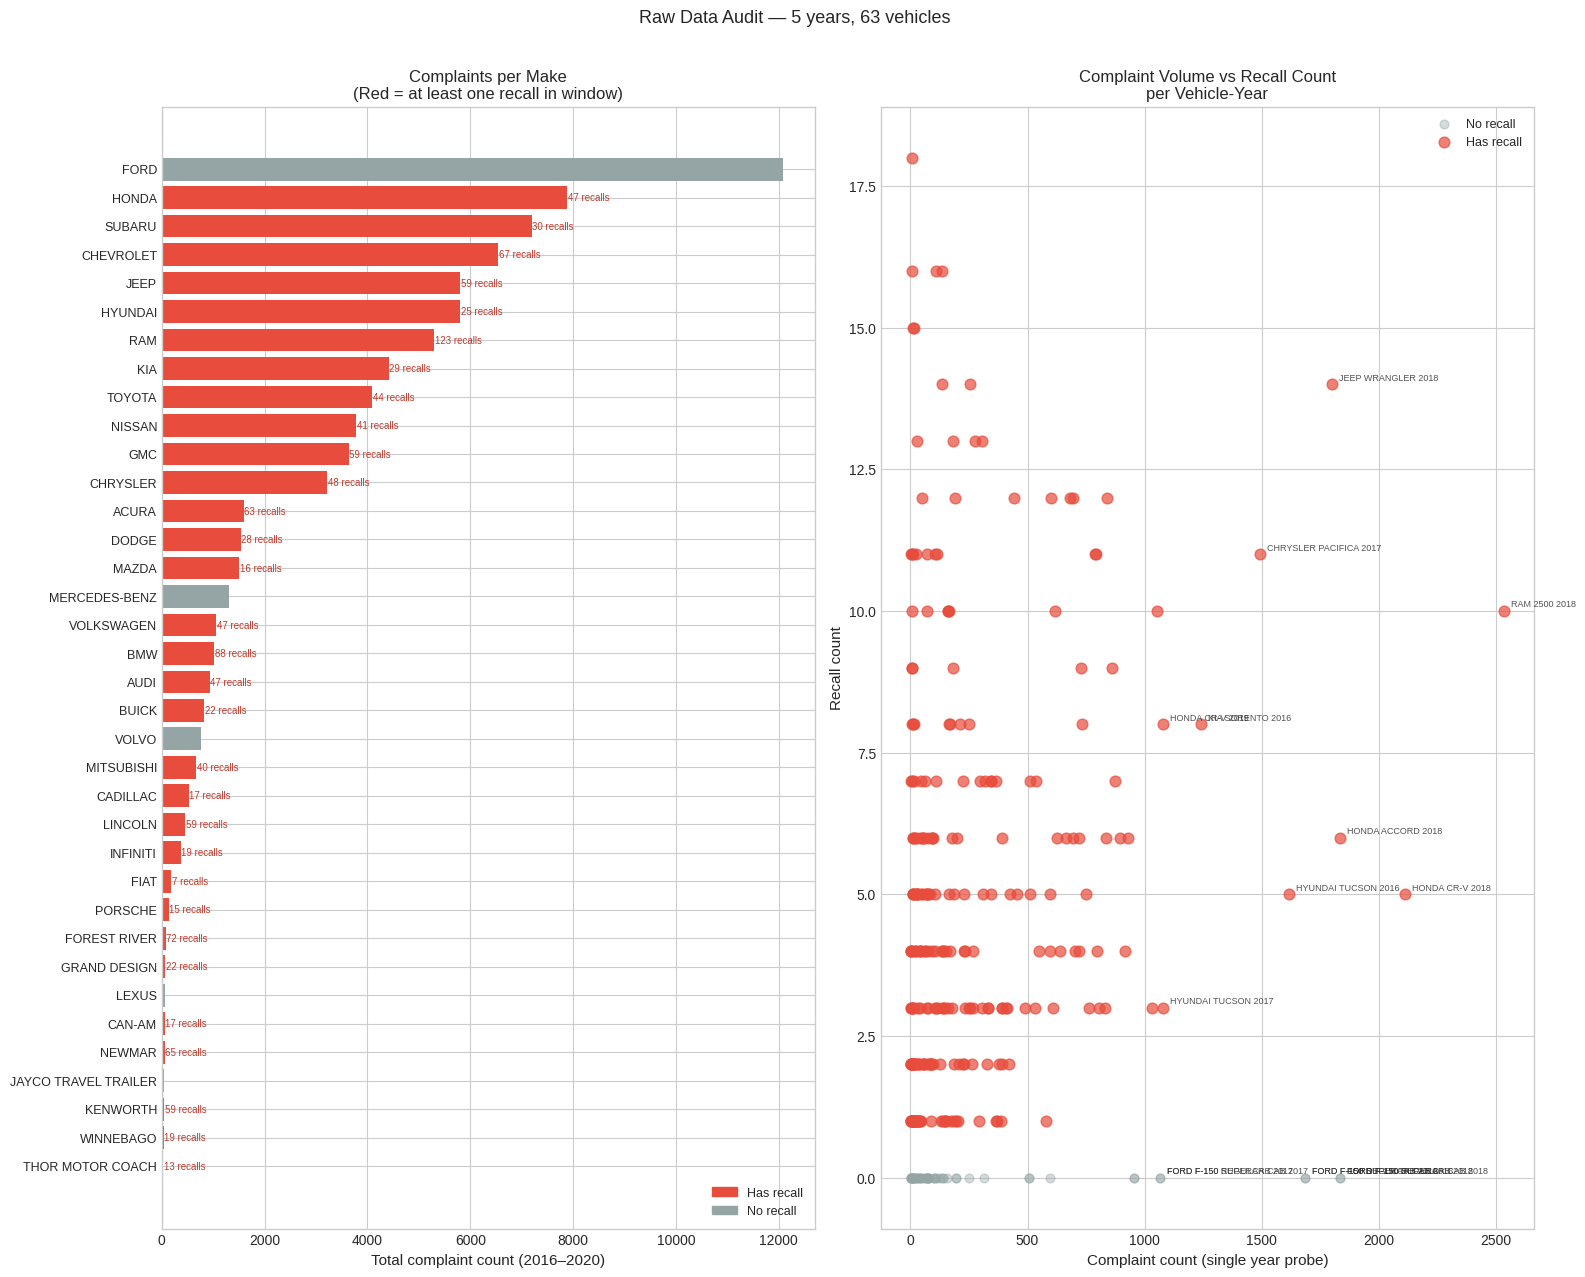


✅ Audit chart saved → data/raw/complaints_vs_recalls_audit.png
✅ Joint summary saved → data/raw/vehicle_joint_summary.csv


In [249]:
# ── Quick visualisation ──

# Panel 1: aggregate to make level — too many vehicle-year rows to plot individually
make_summary = (
    joint
    .groupby("make_pulled")
    .agg(
        total_complaints=("complaint_count", "sum"),
        total_recalls=("recall_count", "sum"),
        has_any_recall=("has_recall", "max"),        # 1 if ANY year had a recall
        vehicle_years=("vehicle_key", "count"),
    )
    .reset_index()
    .sort_values("total_complaints", ascending=True)  # ascending for barh readability
)

fig, axes = plt.subplots(1, 2, figsize=(16, max(6, len(make_summary) * 0.35)))

# ── Panel 1: complaints per MAKE (aggregated across all years) ──
ax1 = axes[0]
colors = ["#e74c3c" if r else "#95a5a6" for r in make_summary["has_any_recall"]]
bars = ax1.barh(make_summary["make_pulled"], make_summary["total_complaints"], color=colors)
ax1.set_xlabel("Total complaint count (2016–2020)", fontsize=11)
ax1.set_title("Complaints per Make\n(Red = at least one recall in window)", fontsize=12)
ax1.tick_params(axis="y", labelsize=9)

from matplotlib.patches import Patch
ax1.legend(handles=[
    Patch(color="#e74c3c", label="Has recall"),
    Patch(color="#95a5a6", label="No recall"),
], loc="lower right", fontsize=9)

# Annotate recall count on bars that have recalls
for _, row in make_summary[make_summary["total_recalls"] > 0].iterrows():
    idx = make_summary["make_pulled"].tolist().index(row["make_pulled"])
    ax1.text(
        row["total_complaints"] + 10,
        idx,
        f"{int(row['total_recalls'])} recalls",
        va="center", fontsize=7, color="#c0392b",
    )

# ── Panel 2: scatter at vehicle-year level (keep as-is — it's readable) ──
ax2 = axes[1]

# Separate recalled vs non-recalled for layering
no_recall = joint[joint["has_recall"] == 0]
has_recall = joint[joint["has_recall"] == 1]

ax2.scatter(
    no_recall["complaint_count"], no_recall["recall_count"],
    alpha=0.4, s=40, color="#95a5a6", label="No recall", zorder=2,
)
ax2.scatter(
    has_recall["complaint_count"], has_recall["recall_count"],
    alpha=0.7, s=60, color="#e74c3c", label="Has recall", zorder=3,
)

# Label only the top-15 by complaint count — keeps scatter readable
top_labels = joint.nlargest(15, "complaint_count")
for _, row in top_labels.iterrows():
    ax2.annotate(
        row["vehicle_key"].replace("_", " "),
        (row["complaint_count"], row["recall_count"]),
        fontsize=6.5, alpha=0.8,
        xytext=(5, 3), textcoords="offset points",
    )

ax2.set_xlabel("Complaint count (single year probe)", fontsize=11)
ax2.set_ylabel("Recall count", fontsize=11)
ax2.set_title("Complaint Volume vs Recall Count\nper Vehicle-Year", fontsize=12)
ax2.legend(fontsize=9)

plt.suptitle(
    f"Raw Data Audit — {len(YEARS_TO_TARGET)} years, {len(VEHICLES)} vehicles",
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.savefig("data/raw/complaints_vs_recalls_audit.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ Audit chart saved → data/raw/complaints_vs_recalls_audit.png")

# Save the joint summary — used in Notebook 6 for validation
joint.to_csv("data/raw/vehicle_joint_summary.csv", index=False)
print("✅ Joint summary saved → data/raw/vehicle_joint_summary.csv")

In [250]:
# ──— Checkpoint: confirm all raw files exist ──────────────
# If any file is missing, re-run the corresponding cell above.
# ───────────────────────────────────────────────────────────────────

expected_files = {
    "data/raw/complaints_raw.csv":          df_complaints,
    "data/raw/recalls_raw.csv":             df_recalls,
    "data/raw/vehicle_catalogue_full.csv":  df_catalogue,
    "data/raw/vehicle_catalogue_selected.csv": df_selected,
    "data/raw/vehicle_joint_summary.csv":   joint,
}

print("RAW DATA CHECKPOINT")
print("=" * 55)

all_ok = True
for path, df in expected_files.items():
    exists = os.path.exists(path)
    rows   = len(df) if df is not None and len(df) > 0 else 0
    status = "✅" if exists and rows > 0 else "❌"
    if not (exists and rows > 0):
        all_ok = False
    print(f"  {status}  {path:<45} {rows:>6} rows")

print()
if all_ok:
    print("All files present. Safe to proceed to Notebook 2 (preprocessing).")
else:
    print("⚠  Some files missing or empty — re-run the flagged cells above.")
    print("   Most common cause: API timeout or rate limit. Add time.sleep(1.0).")

RAW DATA CHECKPOINT
  ✅  data/raw/complaints_raw.csv                    83091 rows
  ✅  data/raw/recalls_raw.csv                        1320 rows
  ✅  data/raw/vehicle_catalogue_full.csv             1504 rows
  ✅  data/raw/vehicle_catalogue_selected.csv           63 rows
  ✅  data/raw/vehicle_joint_summary.csv               313 rows

All files present. Safe to proceed to Notebook 2 (preprocessing).


## Exploratory Data Analysis for text.
Know your
- null rates,
- lengths,
- character distributions.

In [251]:
# ── Complaints audit ──
print("=" * 60)
print("COMPLAINT DATA AUDIT")
print("=" * 60)

# What fields exist?
print(f"\nShape: {df_complaints.shape}")

# The text column — this is your NLP input
print("=" * 60)
text_col = "summary"   # Main complaint narrative field
print(f"\nText column: '{text_col}'")
print(f"  Null rate: {df_complaints[text_col].isna().mean():.1%}")
print(f"  Empty string rate: {(df_complaints[text_col] == '').mean():.1%}")

# Text length distribution — CRITICAL to understand
df_complaints["text_length"] = df_complaints[text_col].fillna("").str.len()
df_complaints["word_count"]  = df_complaints[text_col].fillna("").str.split().str.len()

print("=" * 60)
print(f"\nText length (characters):")
print(df_complaints["text_length"].describe().round(0))

print("=" * 60)
print(f"\nWord count:")
print(df_complaints["word_count"].describe().round(0))


COMPLAINT DATA AUDIT

Shape: (83091, 17)

Text column: 'summary'
  Null rate: 0.0%
  Empty string rate: 0.0%

Text length (characters):
count    83091.0
mean       571.0
std        425.0
min          0.0
25%        263.0
50%        479.0
75%        745.0
max       2647.0
Name: text_length, dtype: float64

Word count:
count    83091.0
mean       100.0
std         75.0
min          0.0
25%         47.0
50%         83.0
75%        129.0
max        439.0
Name: word_count, dtype: float64


In [252]:

# ── What does a real complaint look like? ──
print("\n" + "=" * 60)
print("SAMPLE COMPLAINTS (read these carefully)")
print("=" * 60)

for _, row in df_complaints.dropna(subset=[text_col]).head(5).iterrows():
    print(f"\n[{row.get('make_pulled')} {row.get('model_pulled')} {row.get('year_pulled')}]")
    print(f"Component: {row.get('component', 'N/A')}")
    print(f"Crash: {row.get('crash', 'N/A')} | Injury: {row.get('injury', 'N/A')}")
    print(f"Text: {str(row.get(text_col, ''))[:200]}")
    print("-" * 40)

# ── Complaints per vehicle ──
print("\n" + "=" * 60)
print("COMPLAINTS PER VEHICLE")
print("=" * 60)
summary = df_complaints.groupby(["make_pulled", "model_pulled", "year_pulled"]).size()
print(summary.sort_values(ascending=False).to_string())


SAMPLE COMPLAINTS (read these carefully)

[ACURA MDX 2016]
Component: N/A
Crash: False | Injury: N/A
Text: The contact owns a 2016 Acura MDX. The contact stated that while driving at an undisclosed speed, several unknown warning lights illuminated. The vehicle was not diagnosed or repaired by an independen
----------------------------------------

[ACURA MDX 2016]
Component: N/A
Crash: False | Injury: N/A
Text: I received a letter from Acura about a safety recall on the subframe. My car has been making a creaking noise and so I called the number on the letter. The guy gave me the number to Acura, Brookfield 
----------------------------------------

[ACURA MDX 2016]
Component: N/A
Crash: False | Injury: N/A
Text: The contact called on behalf of the owner of a 2016 Acura MDX. The contact stated that the owner reported an abnormal knocking sound coming from the engine while starting the vehicle. No warning light
----------------------------------------

[ACURA MDX 2016]
Component: N/A
C

## Save Raw Data (Always Checkpoint)
 In Colab, session data is lost when runtime disconnects.

In [253]:
# Create folder structure
os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)
os.makedirs("data/outputs", exist_ok=True)

df_complaints.to_csv("data/raw/complaints_raw.csv", index=False)
df_recalls.to_csv("data/raw/recalls_raw.csv", index=False)

print(f"✅ Saved {len(df_complaints):,} complaints → data/raw/complaints_raw.csv")
print(f"✅ Saved {len(df_recalls):,} recalls    → data/raw/recalls_raw.csv")

# Also mount Google Drive for persistence (optional but recommended)
# from google.colab import drive
# drive.mount('/content/drive')
# df_complaints.to_csv('/content/drive/MyDrive/nhtsa_project/complaints_raw.csv', index=False)

✅ Saved 83,091 complaints → data/raw/complaints_raw.csv
✅ Saved 1,320 recalls    → data/raw/recalls_raw.csv


# NLP Context

In [254]:
## Reload and Reinsall
# CELL 2.0 — Reload (run if starting fresh session)
import pandas as pd
import numpy as np
import re
import string
from collections import Counter

df_complaints = pd.read_csv("data/raw/complaints_raw.csv")
df_recalls    = pd.read_csv("data/raw/recalls_raw.csv")

In [255]:
!pip install -q nltk spacy
import nltk
nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("punkt_tab", quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

print(f"✅ Loaded {len(df_complaints):,} complaints, {len(df_recalls):,} recalls")

✅ Loaded 83,091 complaints, 1,320 recalls


## clean the texts

In [256]:
# CELL 2.1 — Demonstrate the vocabulary problem

TEXT_COL = "summary"
raw_texts = df_complaints[TEXT_COL].dropna().tolist()

# Count raw vocabulary
raw_tokens = []
for text in raw_texts[:500]:  # Sample for speed
    raw_tokens.extend(text.split())

raw_vocab = Counter(raw_tokens)

print(f"Raw vocabulary size (first 500 complaints): {len(raw_vocab):,}")
print(f"\nTop 20 raw tokens:")
for token, count in raw_vocab.most_common(20):
    print(f"  '{token}': {count}")

Raw vocabulary size (first 500 complaints): 9,352

Top 20 raw tokens:
  'the': 2637
  'THE': 1326
  'to': 1306
  'and': 1207
  'I': 1069
  'was': 986
  'a': 939
  'The': 796
  'AND': 613
  'TO': 608
  'of': 556
  'vehicle': 505
  'that': 479
  'not': 460
  'in': 458
  'on': 446
  'is': 444
  'A': 429
  'Acura': 421
  'engine': 404


In [257]:
print("\n──── The problem: look at how many near-duplicates exist ────")
# Show fragmented versions of the same concept
interesting = [t for t in raw_vocab if any(
    w in t.lower() for w in ['brake', 'steer', 'engine', 'camera']
)]
print("Fragments of 'brake':", [t for t in interesting if 'brake' in t.lower()][:10])
print("Fragments of 'steer':", [t for t in interesting if 'steer' in t.lower()][:10])

# Lesson: "Brakes", "brakes", "BRAKES", "brake,", "brake." = same concept
# After cleaning they collapse into one token: "brake"


──── The problem: look at how many near-duplicates exist ────
Fragments of 'brake': ['Brake,', 'brakes.', 'brake', 'Brake', 'brakes,', 'BRAKELIGHT', 'BRAKE', 'BRAKES', 'PROBLEM,BRAKE', 'BRAKED']
Fragments of 'steer': ['steering', 'steer', 'steering.', 'steering,', 'steered', 'Steering', 'STEERING', 'STEER', 'STEERING.']


## Build a Domain-Aware Preprocessing Pipeline

In [258]:
# CELL 2.2 — Domain-aware preprocessing pipeline

STOP_WORDS = set(stopwords.words("english"))

# For automotive complaints, some "stop words" carry meaning
# "not", "no", "never" → critical for negation ("brakes NOT working")
KEEP_NEGATIONS = {"not", "no", "never", "without", "none", "nobody"}
DOMAIN_STOP_WORDS = STOP_WORDS - KEEP_NEGATIONS

# Automotive abbreviation expansion
# Why: "ABS" in one complaint, "anti-lock braking" in another = same thing
# TF-IDF sees them as completely different → expand to unify
AUTOMOTIVE_ABBREVIATIONS = {
    r"\babs\b":   "antilock braking system",
    r"\baeb\b":   "automatic emergency braking",
    r"\bfcw\b":   "forward collision warning",
    r"\becu\b":   "electronic control unit",
    r"\bais\b":   "airbag inflator system",
    r"\blks\b":   "lane keeping system",
    r"\bacc\b":   "adaptive cruise control",
    r"\bepas\b":  "electric power assisted steering",
    r"\btpms\b":  "tire pressure monitoring system",
    r"\bmy\b":    "model year",
    r"\bvin\b":   "vehicle identification number",
    r"\bdtc\b":   "diagnostic trouble code",
}

lemmatizer = WordNetLemmatizer()


# pos aware lematizing where every word is not noun

from nltk import pos_tag
from nltk.corpus import wordnet

nltk.download("averaged_perceptron_tagger_eng", quiet=True)

def get_wordnet_pos(treebank_tag: str) -> str:
  """
  Map NLTK POS tag to WordNet POS tag.
  WordNet only has 4 categories that matter for lemmatization.
  Everything else defaults to noun (no change from lemmatizer default).
  """
  if treebank_tag.startswith("V"):
      return wordnet.VERB      # driving → drive, stated → state
  elif treebank_tag.startswith("J"):
      return wordnet.ADJ       # broken → broken (usually no change)
  elif treebank_tag.startswith("R"):
      return wordnet.ADV       # rarely changes
  else:
      return wordnet.NOUN      # default

def lemmatize_with_pos(tokens: list[str]) -> list[str]:
  """POS-aware lemmatization. Verbs now correctly reduce to base form."""
  tagged = pos_tag(tokens)     # [("driving", "VBG"), ("stated", "VBD"), ...]
  return [
      lemmatizer.lemmatize(word, get_wordnet_pos(tag))
      for word, tag in tagged
  ]



In [259]:

def preprocess_complaint(text: str) -> dict:
    """
    Full preprocessing pipeline. Returns both cleaned text AND
    intermediate steps so you can learn what each step does.
    """
    if not text or not isinstance(text, str):
        return {"cleaned": "", "tokens": [], "steps": {}}

    steps = {}
    steps["0_original"] = text[:80]

    # Step 1: Lowercase
    step1 = text.lower()
    steps["1_lowercase"] = step1[:80]

    # Step 2: Expand abbreviations (do BEFORE removing punctuation)
    step2 = step1
    for pattern, expansion in AUTOMOTIVE_ABBREVIATIONS.items():
        step2 = re.sub(pattern, expansion, step2, flags=re.IGNORECASE)
    steps["2_abbr_expanded"] = step2[:80]

    # Step 3: Remove URLs and emails
    step3 = re.sub(r"https?://\S+|www\.\S+|\S+@\S+", " ", step2)
    steps["3_urls_emails_removed"] = step3[:80]

    # Step 4: Handle special chars — replace with space (not delete!)
    # Deleting: "anti-lock" → "antilock" ✅  vs "end-to-end" → "endtoend" ❌
    step4 = re.sub(r"[^\w\s]", " ", step3)
    steps["4_punct_removed"] = step4[:80]

    # Step 5: Normalise repeated characters ("BRAAAKES" → "brakes")
    step5 = re.sub(r"(.)\1{2,}", r"\1", step4)
    steps["5_repeated_chars_removed"] = step5[:80]

    # Step 6: Normalise whitespace
    step6 = re.sub(r"\s+", " ", step5).strip()
    steps["6_whitespace_normalised"] = step6[:80]

    # Step 7: Tokenize
    tokens = word_tokenize(step6)
    steps["7_tokenized"] = tokens[:10]

    # Step 8: Remove stop words (keep negations!)
    tokens_no_stops = [t for t in tokens if t not in DOMAIN_STOP_WORDS and len(t) > 1]
    steps["8_stopwords_removed"] = tokens_no_stops[:10]

    # Step 9: POS-aware lemmatization
    lemmatized = lemmatize_with_pos(tokens_no_stops)
    steps["9_lemmatized"] = lemmatized[:10]

    cleaned = " ".join(lemmatized)

    return {
        "cleaned": cleaned,
        "tokens": lemmatized,
        "steps": steps,
    }


# ── DEMO: Show each step for one real complaint ──
sample_text = df_complaints[TEXT_COL].dropna().iloc[12]
print("=" * 70)
print("PREPROCESSING WALK-THROUGH")
print("=" * 70)
print(f"\nORIGINAL:\n{sample_text[:300]}")
print()

result = preprocess_complaint(sample_text)
for step_name, value in result["steps"].items():
    print(f"{step_name}:")
    print(f"  → {value}")
    print()

PREPROCESSING WALK-THROUGH

ORIGINAL:
I started the vehicle and steering wheel was frozen and EPS, Brake, and lane departure lights on the dash. I shut the car off and let it sit for five minutes. Restarted and the steering wheel came back to normal. but all light remained on. I drove the car about half a mile and the lights went off. W

0_original:
  → I started the vehicle and steering wheel was frozen and EPS, Brake, and lane dep

1_lowercase:
  → i started the vehicle and steering wheel was frozen and eps, brake, and lane dep

2_abbr_expanded:
  → i started the vehicle and steering wheel was frozen and eps, brake, and lane dep

3_urls_emails_removed:
  → i started the vehicle and steering wheel was frozen and eps, brake, and lane dep

4_punct_removed:
  → i started the vehicle and steering wheel was frozen and eps  brake  and lane dep

5_repeated_chars_removed:
  → i started the vehicle and steering wheel was frozen and eps  brake  and lane dep

6_whitespace_normalised:
  → i start

## Apply Pipeline to Full Dataset

In [ ]:
# CELL 2.3 — Apply preprocessing to all complaints

from tqdm import tqdm

print("Processing all complaints...")
tqdm.pandas()

# Apply the pipeline
processed = df_complaints[TEXT_COL].fillna("").progress_apply(
    lambda x: preprocess_complaint(x)["cleaned"]
)
df_complaints["text_clean"] = processed
df_complaints["text_tokens"] = df_complaints[TEXT_COL].fillna("").apply(
    lambda x: preprocess_complaint(x)["tokens"]
)
df_complaints["word_count_clean"] = df_complaints["text_clean"].str.split().str.len()

# ── Verify vocabulary reduction ──
raw_vocab_size = len(Counter(
    w for text in df_complaints[TEXT_COL].dropna()
    for w in text.lower().split()
))
clean_vocab_size = len(Counter(
    w for tokens in df_complaints["text_tokens"]
    for w in tokens
))

print(f"\n✅ Preprocessing complete")
print(f"\nVocabulary before cleaning: {raw_vocab_size:,}")
print(f"Vocabulary after cleaning:  {clean_vocab_size:,}")
print(f"Reduction: {(1 - clean_vocab_size/raw_vocab_size):.1%}")
print(f"\nThis means {raw_vocab_size - clean_vocab_size:,} near-duplicate tokens")
print(f"collapsed into the same concepts — cleaner signal for models.")

# Save enriched data
df_complaints.to_csv("data/processed/complaints_cleaned.csv", index=False)

print(f"✅ Saved {len(df_complaints):,} rows → data/processed/complaints_cleaned.csv")
print(f"   Columns saved: {list(df_complaints.columns)}")

Processing all complaints...


 52%|█████▏    | 43033/83091 [07:41<03:28, 192.58it/s]

# RULE-BASED CRITICALITY SCORING

## NLP CONCEPTS: Feature engineering, keyword matching, TF-IDF

## - - - - - - - - - - - - - - - - - - - - - - - - -

In [ ]:
# CELL 3.0 — Reload
import pandas as pd
import numpy as np
from collections import Counter

df_complaints = pd.read_csv("data/processed/complaints_cleaned.csv")
df_recalls    = pd.read_csv("data/raw/recalls_raw.csv")
print(f"✅ Loaded {len(df_complaints):,} complaints")

## Structured Signal Extraction (Always Use What You Have)

In [ ]:
df_complaints.head(2)

In [ ]:
# CELL 3.1 — Structured signal extraction

# NHTSA gives you these structured signals for free — use them first
# They are more reliable than NLP-derived signals

# Crash flag — column exists as 'crash', values are True/False or 1/0
df_complaints["has_crash"] = (
    df_complaints["crash"]
    .fillna(False)
    .astype(bool)
    .astype(int)
)

# Fire flag — 'fire' column present in your data, not used before
df_complaints["has_fire"] = (
    df_complaints["fire"]
    .fillna(False)
    .astype(bool)
    .astype(int)
)

# Injury flag — actual column is 'numberOfInjuries', not 'injury'
df_complaints["has_injury"] = (
    df_complaints["numberOfInjuries"]
    .fillna(0)
    .astype(float)          # cast to float first in case of mixed types
    .gt(0)                  # True if any injuries reported
    .astype(int)
)

# Fatality flag — actual column is 'numberOfDeaths', not 'deaths'
df_complaints["has_fatality"] = (
    df_complaints["numberOfDeaths"]
    .fillna(0)
    .astype(float)
    .gt(0)
    .astype(int)
)

# ── Signal 5: Incident date lag ──────────────────────────────────────
df_complaints["date_incident"] = pd.to_datetime(
    df_complaints["dateOfIncident"], errors="coerce"
)
df_complaints["date_filed"] = pd.to_datetime(
    df_complaints["dateComplaintFiled"], errors="coerce"
)
df_complaints["days_to_file"] = (
    df_complaints["date_filed"] - df_complaints["date_incident"]
).dt.days
df_complaints.loc[df_complaints["days_to_file"] < 0, "days_to_file"] = None

df_complaints["filed_quickly"] = (
    df_complaints["days_to_file"].fillna(999).lt(30).astype(int)
)


# Verification
print("Structured signal extraction complete:")
print(f"  has_crash:    {df_complaints['has_crash'].sum():>5} complaints  "
      f"({df_complaints['has_crash'].mean():.1%})")
print(f"  has_fire:     {df_complaints['has_fire'].sum():>5} complaints  "
      f"({df_complaints['has_fire'].mean():.1%})")
print(f"  has_injury:   {df_complaints['has_injury'].sum():>5} complaints  "
      f"({df_complaints['has_injury'].mean():.1%})")
print(f"  has_fatality: {df_complaints['has_fatality'].sum():>5} complaints  "
      f"({df_complaints['has_fatality'].mean():.1%})")

# Quick sanity check — fatalities should be subset of injuries
assert df_complaints["has_fatality"].sum() <= df_complaints.shape[0], "unexpected fatality count"
print(f"\n  Note: 'fire' column captured — strong standalone recall signal")

In [ ]:
sample = df_complaints["components"].dropna().head(10).tolist()
for s in sample:
    print(repr(s))

In [ ]:
# ── CELL 3.1 addition — Component extraction and risk scoring ────────
import ast

def parse_components(raw) -> list[str]:
    """
    Handles all three formats that appear in the NHTSA components column:
      1. Plain string:       'ENGINE'
      2. Multi-value string: 'ENGINE AND ENGINE COOLING'  ← one entry with 'AND'
      3. List-as-string:     "['ENGINE', 'SUSPENSION']"   ← from JSON serialisation
    Returns a list of individual component strings.
    """
    if not isinstance(raw, str) or not raw.strip():
        return []

    stripped = raw.strip()

    # Case 3: looks like a Python list — parse it
    if stripped.startswith("["):
        try:
            parsed = ast.literal_eval(stripped)
            if isinstance(parsed, list):
                return [str(c).upper().strip() for c in parsed if c]
        except (ValueError, SyntaxError):
            pass

    # Case 1 & 2: plain string — return as single-element list
    # Do NOT split on 'AND' — 'ENGINE AND ENGINE COOLING' is one component
    return [stripped.upper()]


CRITICAL_COMPONENTS = {
    "AIR BAGS":                     95,
    "STEERING":                     90,
    "SERVICE BRAKES":               90,
    "ELECTRICAL SYSTEM":            75,
    "ENGINE AND ENGINE COOLING":    80,
    "ENGINE":                       80,
    "FUEL SYSTEM":                  85,
    "POWER TRAIN":                  75,
    "VEHICLE SPEED CONTROL":        85,
    "TRACTION CONTROL SYSTEM":      70,
    "FORWARD COLLISION AVOIDANCE":  90,
    "LANE DEPARTURE":               70,
    "VISIBILITY":                   65,
    "TIRES":                        70,
    "SUSPENSION":                   65,
    "LATCHES":                      60,
    "EXTERIOR LIGHTING":            50,
    "INTERIOR FEATURES":            20,
    "UNKNOWN OR OTHER":             30,
}

In [ ]:
def component_risk(raw) -> int:
    """
    Parse all components from the field and return the HIGHEST
    risk score across all of them.
    A complaint touching both STEERING and SUSPENSION should score
    as high as its most dangerous component — not average them.
    """
    components = parse_components(raw)
    if not components:
        return 30   # default unknown risk

    scores = []
    for comp in components:
        matched = False
        for key, score in CRITICAL_COMPONENTS.items():
            if key in comp:             # substring match — 'SERVICE BRAKES' in 'SERVICE BRAKES, HYDRAULIC'
                scores.append(score)
                matched = True
                break
        if not matched:
            scores.append(30)           # unknown component

    return max(scores)                  # highest risk across all components


# Apply to all complaints
df_complaints["component_parsed"] = df_complaints["components"].apply(parse_components)
df_complaints["component_risk"]   = df_complaints["components"].apply(component_risk)

# Verification
print("Component extraction complete:")
print(f"  Total complaints:           {len(df_complaints):,}")
print(f"  With parsed components:     {df_complaints['component_parsed'].apply(bool).sum():,}")
print(f"  Empty/missing components:   {df_complaints['component_parsed'].apply(lambda x: len(x)==0).sum():,}")
print(f"\nComponent risk distribution:")
print(df_complaints["component_risk"].value_counts().sort_index(ascending=False))

In [ ]:
# Show a few examples to visually verify parsing is correct
print("\nSample parsed components:")
sample = df_complaints[["components", "component_parsed", "component_risk"]].dropna(subset=["components"])
print(sample.head(8).to_string(index=False))

In [ ]:
# ── Signal 5: Incident date lag (days between incident and complaint filing) ──
# A complaint filed quickly after an incident = owner was alarmed enough
# to act immediately = stronger signal than a complaint filed 2 years later.
# Short lag = acute event. Long lag = chronic/recurring issue.
df_complaints["date_incident"] = pd.to_datetime(
    df_complaints["dateOfIncident"], errors="coerce"
)
df_complaints["date_filed"] = pd.to_datetime(
    df_complaints["dateComplaintFiled"], errors="coerce"
)
df_complaints["days_to_file"] = (
    df_complaints["date_filed"] - df_complaints["date_incident"]
).dt.days

# Negative values = data entry error (incident after filing) → set to NaN
df_complaints.loc[df_complaints["days_to_file"] < 0, "days_to_file"] = None

# Flag: filed within 30 days of incident = acute event
df_complaints["filed_quickly"] = (
    df_complaints["days_to_file"]
    .fillna(999)
    .lt(30)
    .astype(int)
)



In [ ]:
# ── Verification ──
print("Structured signal extraction complete:")
print(f"  has_crash:      {df_complaints['has_crash'].sum():>6,} complaints  "
      f"({df_complaints['has_crash'].mean():.1%})")
print(f"  has_fire:       {df_complaints['has_fire'].sum():>6,} complaints  "
      f"({df_complaints['has_fire'].mean():.1%})")
print(f"  has_injury:     {df_complaints['has_injury'].sum():>6,} complaints  "
      f"({df_complaints['has_injury'].mean():.1%})")
print(f"  has_fatality:   {df_complaints['has_fatality'].sum():>6,} complaints  "
      f"({df_complaints['has_fatality'].mean():.1%})")
print(f"  filed_quickly:  {df_complaints['filed_quickly'].sum():>6,} complaints  "
      f"({df_complaints['filed_quickly'].mean():.1%})")

print(f"\nDays-to-file distribution (where available):")
print(df_complaints["days_to_file"].describe().round(1))

print(f"\nComponent risk distribution:")
print(df_complaints["component_risk"].value_counts().sort_index(ascending=False).head(8))

## Rule-Based Keyword Criticality Scoring

- Keyword matching — the simplest possible NLP.

- Always implement this first. It's your interpretable baseline.

A rule-based system tells you what to beat with fancier methods.

In [ ]:
# Safety-critical vocabulary — curated from NHTSA recall terminology

# Key changes vs original:
#   - Baseline dropped from 30 → 5 (earn your score, don't start high)
#   - Tier 2 words ("failed", "malfunction") moved to Tier 3 — weak signal
#   - Tier 1 requires genuine danger words, not generic complaint words
#   - Caps per tier prevent a complaint with 10 weak words
#     from outscoring one with 1 strong word

TIER1_DANGER = [
    "fire", "explode", "explosion", "rollaway", "roll away",
    "loss of control", "unintended acceleration", "sudden acceleration",
    "cannot stop", "no brakes", "brake fail", "brake failure",
    "airbag deploy", "airbag explode", "death", "fatality", "died",
    "serious injury", "hospitalized",
]

TIER2_SAFETY = [
    "crash", "accident", "collision", "injury", "injured",
    "unsafe", "dangerous", "hazard", "stall", "stalled",
    "sudden", "unexpected", "without warning", "spontaneous",
    "airbag", "air bag",
]

TIER3_WEAK = [
    "failed", "failure", "malfunction", "broken", "defect",
    "recall", "not working", "problem", "issue",
]

def keyword_score_recalibrated(text: str) -> dict:
    """
    Keyword criticality score. Baseline = 5.
    Most complaints score 5–30. Genuinely dangerous ones score 60+.

    Returns a dicti with :
      score : numeric criticality score (0-100)
      keywords_found : list of keywords found in text
      tier_summary : short string showing how many hits per tier
    """

    if not isinstance(text, str) or not text.strip():
        return {"score": 5.0, "keywords_found": [], "tier_summary": "no text"}

    t = text.lower()
    score = 5.0
    found = []

    # Tier 1: strong danger signal, each hit worth 20, cap at 3 hits
    t1_words = [w for w in TIER1_DANGER if w in t]
    t1_hits  = min(len(t1_words), 3)
    score   += t1_hits * 20
    found   += [f"[T1]{w}" for w in t1_words[:3]]   # prefix shows which tier

    # Tier 2: moderate safety signal, each hit worth 10, cap at 3 hits
    t2_words = [w for w in TIER2_SAFETY if w in t]
    t2_hits  = min(len(t2_words), 3)
    score   += t2_hits * 10
    found   += [f"[T2]{w}" for w in t2_words[:3]]

    # Tier 3: weak signal, each hit worth 3, cap at 4 hits
    t3_words = [w for w in TIER3_WEAK if w in t]
    t3_hits  = min(len(t3_words), 4)
    score   += t3_hits * 3
    found   += [f"[T3]{w}" for w in t3_words[:4]]

    tier_summary = f"T1:{t1_hits} T2:{t2_hits} T3:{t3_hits}"

    return {
        "score":          round(min(100.0, score), 1),
        "keywords_found": found,
        "tier_summary":   tier_summary,
    }



In [ ]:
text_col = "text_clean" if "text_clean" in df_complaints.columns else "summary"
print(f"Applying keyword scoring on '{text_col}' for {len(df_complaints):,} complaints...")

scoring_results = df_complaints[text_col].fillna("").apply(keyword_score_recalibrated)

df_complaints["keyword_score"]   = scoring_results.apply(lambda x: x["score"])
df_complaints["keywords_found"]  = scoring_results.apply(lambda x: x["keywords_found"])
df_complaints["tier_summary"]    = scoring_results.apply(lambda x: x["tier_summary"])

print(f"\nKeyword score distribution:")
print(df_complaints["keyword_score"].describe().round(1))
print()

bands   = [0, 10, 25, 40, 55, 70, 100]
blabels = ["0-10", "10-25", "25-40", "40-55", "55-70", "70-100"]
cuts = pd.cut(df_complaints["keyword_score"], bins=bands, labels=blabels)
for band, count in cuts.value_counts().sort_index().items():
    bar = "█" * int(count / len(df_complaints) * 40)
    print(f"  {band:<8} {count:>7,} ({count/len(df_complaints):>5.1%})  {bar}")

print(f"\n✅ Columns added: keyword_score, keywords_found, tier_summary")


In [ ]:
# ── CELL 3.4 — Validate keyword score separation (replaces composite validation) ──
import matplotlib.pyplot as plt

# Quality gate for Notebook 3: does keyword_score separate
# flagged from unflagged complaints?
# This is what matters before saving — the composite validation
# happens in Notebook 4 after ML training.

flagged = (
    (df_complaints["has_crash"]    == 1) |
    (df_complaints["has_injury"]   == 1) |
    (df_complaints["has_fatality"] == 1) |
    (df_complaints["has_fire"]     == 1)
)

kw_no_flag  = df_complaints[~flagged]["keyword_score"].dropna()
kw_has_flag = df_complaints[flagged]["keyword_score"].dropna()
separation  = kw_has_flag.median() - kw_no_flag.median()

print(f"Keyword score — No flag:  median={kw_no_flag.median():.1f}")
print(f"Keyword score — Has flag: median={kw_has_flag.median():.1f}")
print(f"Separation: {separation:.1f} pts  "
      f"({'✅ good' if separation > 10 else '⚠ check keyword tiers'})")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_complaints["keyword_score"], bins=50, color="#3498db", alpha=0.7)
axes[0].set_xlabel("Keyword Score")
axes[0].set_title("Keyword Score Distribution\n(target: right-skewed, most complaints < 25)")

axes[1].boxplot(
    [kw_no_flag, kw_has_flag],
    labels=[f"No flag\n(n={len(kw_no_flag):,})",
            f"Has flag\n(n={len(kw_has_flag):,})"],
    patch_artist=True,
)
axes[1].set_ylabel("Keyword Score")
axes[1].set_title("Keyword Score by Safety Flag\n(should show clear separation)")

plt.tight_layout()
plt.savefig("data/outputs/keyword_score_validation.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
df_complaints.columns

In [ ]:
# ── Show examples ──
print("\n── HIGH CRITICALITY EXAMPLES ──")
high = df_complaints.nlargest(3, "keyword_score")

for _, row in high.iterrows():
    print(f"\nScore: {row['keyword_score']:.0f} | "
          f"Make: {row.get('make_pulled')} | Component: {row.get('component', 'N/A')}")
    print(f"Keywords triggered: {row['keywords_found']}")
    print(f"Text: {str(row.get('summary', ''))[:200]}")

print("\n── LOW CRITICALITY EXAMPLES ──")
low = df_complaints.nsmallest(3, "keyword_score")
for _, row in low.iterrows():
    print(f"\nScore: {row['keyword_score']:.0f} | Text: {str(row.get('summary', ''))[:150]}")

In [ ]:
# ── SAVE: End of Notebook 3 ─────────────────────────────────────────
# Columns added since complaints_cleaned.csv:
#   has_crash, has_fire, has_injury, has_fatality
#   date_incident, date_filed, days_to_file, filed_quickly
#   component_parsed, component_risk
#   keyword_score, keywords_found, tiers_triggered

df_complaints.to_csv("data/processed/complaints_scored.csv", index=False)

print(f"✅ Saved {len(df_complaints):,} rows → data/processed/complaints_scored.csv")
print(f"   Columns saved: {list(df_complaints.columns)}")

# Verify the critical columns are all present before saving
required = [
    "text_clean", "has_crash", "has_fire", "has_injury", "has_fatality",
    "component_risk", "keyword_score",
]
missing = [c for c in required if c not in df_complaints.columns]
if missing:
    print(f"⚠  WARNING — these columns are missing and were NOT saved: {missing}")
    print(f"   Re-run Cells 3.1 and 3.2 before saving.")
else:
    print(f"✅ All required signal columns confirmed present")

## TF-IDF Feature Extraction (NLP Layer 2)

NLP CONCEPT: TF-IDF. Moving beyond binary keyword matching
to frequency-weighted vocabulary representation.

In [ ]:
# CELL 3.3 — TF-IDF feature extraction :: Statistical text representation

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ── Build TF-IDF matrix ──
# sublinear_tf=True: dampens effect of very common words (log scaling)
# ngram_range=(1,2): capture "brake failure" not just "brake" + "failure"
# max_features: keep top 3000 most informative terms

tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),    # Unigrams + bigrams
    sublinear_tf=True,     # Always True for document classification
    min_df=3,              # Word must appear in at least 3 documents
    max_df=0.85,           # Ignore words in > 85% of documents
    token_pattern=r"[a-z][a-z]+",  # Only real words (no single chars)
)

X_tfidf = tfidf.fit_transform(df_complaints["text_clean"].fillna(""))
print(f"TF-IDF matrix shape: {X_tfidf.shape}")
print(f"  → {X_tfidf.shape[0]} complaints × {X_tfidf.shape[1]} features")
print(f"  → Sparsity: {1 - X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]):.1%}")

# ── Which terms are most discriminating for SAFETY complaints? ──
feature_names = tfidf.get_feature_names_out()

# Use the keyword score to identify high-criticality complaints
high_crit_mask  = df_complaints["keyword_score"] > 70
low_crit_mask   = df_complaints["keyword_score"] < 30

X_high = X_tfidf[high_crit_mask.values]
X_low  = X_tfidf[low_crit_mask.values]

# Mean TF-IDF per term for each group
mean_high = np.array(X_high.mean(axis=0)).flatten()
mean_low  = np.array(X_low.mean(axis=0)).flatten()

# Discriminative terms = high in critical complaints, low in non-critical
discriminative_idx = np.argsort(mean_high - mean_low)[::-1][:20]
print(f"\nTop 20 terms most predictive of CRITICAL complaints:")
for i, idx in enumerate(discriminative_idx):
    term = feature_names[idx]
    high_score = mean_high[idx]
    low_score  = mean_low[idx]
    print(f"  {i+1:2d}. '{term}' (critical avg: {high_score:.4f}, non-critical: {low_score:.4f})")

# INSIGHT: These discriminative terms are your NLP model's "vocabulary of danger"
# If you were to inspect what separates crashes from cosmetics, it's these terms.

# ML-BASED CRITICALITY CLASSIFICATION (NLP Layer 3)

## "Let the model learn what 'critical' means"
NLP CONCEPTS:
- Supervised classification,
- feature engineering,
- Word2Vec embeddings,
- model comparison

In [ ]:
# ── CELL 4.0 — Reload ───────────────────────────────────────────────
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, f1_score
import matplotlib.pyplot as plt

# Load from complaints_scored.csv — not complaints_cleaned.csv.
# complaints_scored has all derived signal columns from Notebook 3.
# complaints_cleaned only has preprocessed text — no risk signals.
df_complaints = pd.read_csv("data/processed/complaints_scored.csv")
df_recalls    = pd.read_csv("data/raw/recalls_raw.csv")

print(f"✅ Loaded {len(df_complaints):,} complaints")
print(f"   Columns: {list(df_complaints.columns)}")

# Confirm the columns Cell 4.1 depends on are present
required = [
    "text_clean", "has_crash", "has_fire", "has_injury",
    "has_fatality", "component_risk", "keyword_score",
]
missing = [c for c in required if c not in df_complaints.columns]
if missing:
    raise FileNotFoundError(
        f"Required columns missing from complaints_scored.csv: {missing}\n"
        f"Re-run Notebook 3 (Cells 3.1 and 3.2) and save before reloading here."
    )
print(f"✅ All signal columns confirmed present — ready for Cell 4.1")

## CELL 4.1 — Create Training Labels from Structured Signals

NLP CONCEPT:

    - Weak supervision / label creation.
    - You rarely have perfect labels. Here you create "silver labels"
    - from structured signals (crash flag, injury flag) to train a model
    - that can then generalise to complaints where those flags are missing.

In [ ]:
# ── CELL 4.1 — Create training labels ────────────────────

# STRATEGY: Use NHTSA's structured flags as "silver labels"
# Crash = 1 or Injury = 1 → CRITICAL (positive class)
# Component risk < 40 AND keyword score < 30 → NON-CRITICAL (negative class)
# Everything in between → exclude from training (uncertainty zone)

# ── CELL 4.1 — Create training labels ────────────────────────────────
# All signal columns (has_crash, has_fire, has_injury, has_fatality,
# component_risk, keyword_score, text_clean) are guaranteed present
# from complaints_scored.csv loaded in Cell 4.0.
# No guards or rebuilds needed here.

# ── Step 1: Assign silver labels ──
# CRITICAL     = any structural safety flag is set
# NON-CRITICAL = low keyword score + low component risk + no safety flags
# UNCERTAIN    = everything in between → excluded from training

critical_mask = (
    (df_complaints["has_crash"]    == 1) |
    (df_complaints["has_injury"]   == 1) |
    (df_complaints["has_fatality"] == 1) |
    (df_complaints["has_fire"]     == 1)
)

non_critical_mask = (
    (df_complaints["keyword_score"]  < 25) &
    (df_complaints["component_risk"] < 40) &
    (df_complaints["has_crash"]      == 0) &
    (df_complaints["has_injury"]     == 0) &
    (df_complaints["has_fatality"]   == 0) &
    (df_complaints["has_fire"]       == 0)
)

df_critical     = df_complaints[critical_mask].copy()
df_non_critical = df_complaints[non_critical_mask].copy()

df_critical["label"]     = 1
df_non_critical["label"] = 0

total = len(df_complaints)
print("Silver label breakdown:")
print(f"  CRITICAL:     {len(df_critical):>6,}  ({len(df_critical)/total:.1%})")
print(f"  NON-CRITICAL: {len(df_non_critical):>6,}  ({len(df_non_critical)/total:.1%})")
print(f"  UNCERTAIN:    {total - len(df_critical) - len(df_non_critical):>6,}  "
      f"(excluded — too ambiguous for silver labelling)")

# Sanity check: critical set should have meaningful positive rate
# If it's < 1% something is wrong with the flag columns
critical_rate = len(df_critical) / total
if critical_rate < 0.01:
    print(f"\n⚠  WARNING: only {critical_rate:.2%} critical — check has_crash/has_injury columns")
elif critical_rate > 0.40:
    print(f"\n⚠  WARNING: {critical_rate:.2%} critical — thresholds may be too loose")
else:
    print(f"\n✅ Critical rate {critical_rate:.1%} — looks reasonable")

# ── Step 2: Balance and build training set ──
n_critical = len(df_critical)
n_sample   = min(len(df_non_critical), n_critical * 3)  # max 3:1 ratio
df_non_critical_sampled = df_non_critical.sample(n_sample, random_state=42)

df_train = (
    pd.concat([df_critical, df_non_critical_sampled])
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

print(f"\nTraining set: {len(df_train):,} complaints")
print(f"  Critical:     {df_train['label'].sum():,} ({df_train['label'].mean():.1%})")
print(f"  Non-critical: {(1-df_train['label']).sum():,} ({(1-df_train['label']).mean():.1%})")

X_text = df_train["text_clean"].fillna("").tolist()
y      = df_train["label"].tolist()

print(f"\n✅ Training set ready — {len(X_text):,} samples")


## CELL 4.2 — Classical ML: Compare Three Models

NLP CONCEPT: The baseline-first principle.
- Naive Bayes → Logistic Regression → SVM.

Each step up adds complexity. You only move up the stack when the simpler model is insufficient.

In [ ]:
# CELL 4.2 — Systematic model comparison

from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.calibration import CalibratedClassifierCV

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipelines = {
    "NaiveBayes (baseline)": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1,1), sublinear_tf=True)),
        ("clf",   ComplementNB(alpha=0.1)),
    ]),
    "LogisticRegression": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=8000, ngram_range=(1,2), sublinear_tf=True)),
        ("clf",   LogisticRegression(C=1.0, class_weight="balanced", max_iter=1000)),
    ]),
    "LinearSVM": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=8000, ngram_range=(1,2), sublinear_tf=True)),
        ("clf",   CalibratedClassifierCV(
            LinearSVC(C=1.0, class_weight="balanced", max_iter=2000), cv=3
        )),
    ]),
}


In [ ]:
results = {}
print("Running 5-fold cross-validation...\n")

for name, pipeline in pipelines.items():
    scores = cross_val_score(pipeline, X_text, y, cv=cv, scoring="f1")
    results[name] = {
        "f1_mean": scores.mean(),
        "f1_std":  scores.std(),
        "scores":  scores,
    }
    print(f"{name}:")
    print(f"  F1: {scores.mean():.3f} ± {scores.std():.3f}")
    print(f"  Scores: {[f'{s:.3f}' for s in scores]}\n")

# ── What did you learn? ──
best_model_name = max(results, key=lambda k: results[k]["f1_mean"])
print(f"\n✅ Best model: {best_model_name}")
print("\nNLP LESSON: LinearSVM almost always wins on text classification.")
print("Logistic Regression is close and gives calibrated probabilities.")
print("Naive Bayes is fast but weaker on bigrams and negation.")

## CELL 4.3 — Train Final Classifier and Inspect What It Learned

In [ ]:
# Linear classifiers (LogReg, SVM) have inspectable weights.
# The most important NLP skill: being able to explain model decisions.

# CELL 4.3 — Train final model and inspect features

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

# Use Logistic Regression (gives probabilities — needed for scoring)
final_pipeline = Pipeline([
    ("tfidf",
     TfidfVectorizer( max_features=8000,
                     ngram_range=(1,2),
                     sublinear_tf=True,
                    min_df=2,
                    )
     ),
    ("clf",
     LogisticRegression(C=1.0,
                        class_weight="balanced",
                        max_iter=1000,
                        )
     ),
])

final_pipeline.fit(X_train, y_train)

# Evaluate
y_pred  = final_pipeline.predict(X_test)
y_proba = final_pipeline.predict_proba(X_test)[:, 1]

print('='*80)
print("CLASSIFICATION REPORT:")
print('='*80)
print()
print(classification_report(y_test, y_pred, target_names=["Non-Critical", "Critical"]))

# ── Feature inspection ──
vectorizer = final_pipeline.named_steps["tfidf"]
clf        = final_pipeline.named_steps["clf"]
feature_names = vectorizer.get_feature_names_out()
coefs = clf.coef_[0]

n_top = 20
top_critical_idx     = np.argsort(coefs)[::-1][:n_top]
top_non_critical_idx = np.argsort(coefs)[:n_top]

print(f"\nTop {n_top} terms pushing toward CRITICAL:")
for i, idx in enumerate(top_critical_idx):
    print(f"  {i+1:2d}. '{feature_names[idx]}' (weight: {coefs[idx]:.3f})")

print(f"\nTop {n_top} terms pushing toward NON-CRITICAL:")
for i, idx in enumerate(top_non_critical_idx):
    print(f"  {i+1:2d}. '{feature_names[idx]}' (weight: {coefs[idx]:.3f})")

# LESSON: These weights tell you EXACTLY what the model learned.
# If "bluetooth" has a strong negative weight → the model learned
# that Bluetooth complaints are not safety-critical. No magic.

## CELL 4.4 — Apply ML Criticality Score to All Complaints

In [ ]:
# ── CELL 4.4 — Final composite score (ML-enhanced) ───────────────────
# This is the SECOND composite in the pipeline.
# Notebook 3 produced composite_score_v1 (deterministic, used for labels).
# This cell produces the final composite_score using the trained ML model.
# The ML model adds signal the keyword tier list cannot capture:
#   - sentence structure and context
#   - negation ("brakes NOT working" vs "brakes working fine")
#   - learned patterns from the full training set

all_texts        = df_complaints["text_clean"].fillna("").tolist()
ml_proba         = final_pipeline.predict_proba(all_texts)[:, 1]
df_complaints["ml_score"] = ml_proba * 100   # scale to 0-100

# ── Final composite formula ───────────────────────────────────────────
# Weights reflect what each component actually measures:
#
#   ml_score     (50%) — learned pattern from text, highest weight
#   keyword_score(30%) — recalibrated deterministic signal (mean=16)
#   flags        (—)   — hard boosts: ground truth overrides everything
#   component    (—)   — small additive, reduced weight (see Notebook 3)
#
# NOTE: keyword_score here is the RECALIBRATED version (mean=16, not 70).
# The ml_score was trained on labels derived from that recalibrated score.
# Both components now live on compatible scales.

def final_composite(row) -> float:
    score = 0.0

    # ML probability — primary learned signal
    score += row["ml_score"] * 0.50

    # Recalibrated keyword score — deterministic anchor
    # Prevents ML overconfidence on ambiguous text
    score += row["keyword_score"] * 0.30

    # Structured flags — hard boosts, ground truth signal
    # These override ambiguous ML/keyword scores
    score += row["has_crash"]    * 45
    score += row["has_injury"]   * 35
    score += row["has_fatality"] * 50
    score += row["has_fire"]     * 40

    # Component risk — small additive (reduced from Notebook 3)
    score += max(0, row["component_risk"] - 30) * 0.05

    # Filed quickly — acute event signal
    score += row.get("filed_quickly", 0) * 5

    return round(min(100.0, score), 2)

print("Computing final composite scores...")
df_complaints["composite_score"] = df_complaints.apply(final_composite, axis=1)

# ── Validate before saving ────────────────────────────────────────────
flagged = (
    (df_complaints["has_crash"]    == 1) |
    (df_complaints["has_injury"]   == 1) |
    (df_complaints["has_fatality"] == 1) |
    (df_complaints["has_fire"]     == 1)
)

no_flag_scores  = df_complaints[~flagged]["composite_score"]
has_flag_scores = df_complaints[flagged]["composite_score"]
separation      = has_flag_scores.median() - no_flag_scores.median()

print(f"\nFinal composite score distribution:")
print(df_complaints["composite_score"].describe().round(1))
print(f"\nSeparation check:")
print(f"  Unflagged median: {no_flag_scores.median():.1f}")
print(f"  Flagged median:   {has_flag_scores.median():.1f}")
print(f"  Separation:       {separation:.1f} pts  "
      f"({'✅ good' if separation > 20 else '⚠ check weights'})")

# ML contribution check — does ML add anything beyond keyword alone?
keyword_only = df_complaints["keyword_score"] * 0.30
ml_contrib   = df_complaints["ml_score"]      * 0.50
print(f"\nML vs keyword contribution (mean):")
print(f"  Keyword term:  {keyword_only.mean():.1f} pts")
print(f"  ML term:       {ml_contrib.mean():.1f} pts")
print(f"  ML adds:       {ml_contrib.mean() - keyword_only.mean():+.1f} pts on average")

In [ ]:
# ── Re-derive SBERT threshold from final composite ───────────────────
# The final composite will have a slightly different distribution
# than the Notebook 3 deterministic version.
# Re-derive the natural valley threshold.

import numpy as np
import json

scores   = df_complaints["composite_score"].values
hist, bin_edges = np.histogram(scores, bins=100)

# Find valley between the two clusters (between scores 25 and 65)
mid_mask = (bin_edges[:-1] >= 25) & (bin_edges[:-1] <= 65)
valley_idx      = hist[mid_mask].argmin()
SBERT_THRESHOLD = round(float(bin_edges[:-1][mid_mask][valley_idx]), 1)

above = (df_complaints["composite_score"] >= SBERT_THRESHOLD).sum()
print(f"Updated SBERT threshold (valley): {SBERT_THRESHOLD}")
print(f"Complaints above threshold: {above:,} ({above/len(df_complaints):.1%})")

# Update scoring config
with open("data/processed/scoring_config.json", "w") as f:
    json.dump({
        "sbert_threshold":             SBERT_THRESHOLD,
        "composite_score_mean":        round(df_complaints["composite_score"].mean(), 1),
        "composite_score_std":         round(df_complaints["composite_score"].std(), 1),
        "flagged_pct":                 round(float(flagged.mean()), 4),
        "ml_score_mean":               round(df_complaints["ml_score"].mean(), 1),
        "keyword_score_mean":          round(df_complaints["keyword_score"].mean(), 1),
        "n_complaints":                len(df_complaints),
    }, f, indent=2)

df_complaints.to_csv("data/processed/complaints_scored.csv", index=False)
print(f"\n✅ Saved {len(df_complaints):,} rows → data/processed/complaints_scored.csv")
print(f"✅ Scoring config updated → data/processed/scoring_config.json")

## visualize the distribution of score

In [ ]:
# ── Audit plot ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Panel 1: final composite distribution
axes[0].hist(df_complaints["composite_score"], bins=80, color="#3498db", alpha=0.7)
axes[0].axvline(SBERT_THRESHOLD, color="red", linestyle="--",
                label=f"SBERT threshold ({SBERT_THRESHOLD})")
axes[0].set_xlabel("Composite Score")
axes[0].set_title("Final Composite Distribution")
axes[0].legend()

# Panel 2: separation by flag
bp = axes[1].boxplot(
    [no_flag_scores, has_flag_scores],
    labels=[f"No flag\n(n={len(no_flag_scores):,})",
            f"Has flag\n(n={len(has_flag_scores):,})"],
    patch_artist=True,
)
bp["boxes"][0].set_facecolor("#95a5a6")
bp["boxes"][1].set_facecolor("#e74c3c")
axes[1].axhline(SBERT_THRESHOLD, color="red", linestyle="--", alpha=0.5)
axes[1].set_ylabel("Composite Score")
axes[1].set_title(f"Separation: {separation:.0f} pts")

# Panel 3: ML score vs keyword score scatter (sample)
sample = df_complaints.sample(min(2000, len(df_complaints)), random_state=42)
sc = axes[2].scatter(
    sample["keyword_score"],
    sample["ml_score"],
    c=sample["composite_score"],
    cmap="RdYlGn",
    alpha=0.4, s=10,
)
plt.colorbar(sc, ax=axes[2], label="Composite Score")
axes[2].set_xlabel("Keyword Score (recalibrated)")
axes[2].set_ylabel("ML Score")
axes[2].set_title("Keyword vs ML Score\n(colour = composite)")

plt.tight_layout()
plt.savefig("data/outputs/final_composite_audit.png", dpi=150, bbox_inches="tight")
plt.show()

## Sentence-transformers is the SBERT library
- transformers + pipeline gives us zero-shot classification
- umap-learn for dimensionality reduction (for visualising clusters)
- hdbscan for density-based clustering (better than k-means for text)

In [ ]:
!pip install -q sentence-transformers transformers umap-learn hdbscan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Reload your scored complaints from Notebook 4

df = pd.read_csv("data/processed/complaints_scored.csv")
df["text_clean"] = df["text_clean"].fillna("")

print(f"✅ Loaded {len(df):,} scored complaints")
print(f"Composite score range: {df['composite_score'].min():.1f} – {df['composite_score'].max():.1f}")
print(f"Columns available: {list(df.columns)}")

## TF-IDF vs SBERT on automotive complaints

- THE PROBLEM WITH TF-IDF FOR SEMANTIC TASKS

TF-IDF gives each word a score based on frequency statistics. It has NO concept of meaning.

Example: two complaints about the same defect:

Complaint A: "the steering wheel became unresponsive at 60mph, vehicle drifted into adjacent lane"

Complaint B: "lost control of car direction on highway, wheel would not respond to input"

- TF-IDF cosine similarity between these: ~0.08 (almost zero)
- SBERT cosine similarity between these: ~0.81 (strongly similar)

---

- CLUSTERING: TF-IDF clusters complaints that use the same words. SBERT clusters complaints that describe the same event. For a defect early-warning system, you want defect clusters, not word clusters.
- PATTERN DETECTION: "10 complaints about the same problem" only works if you can recognise that they ARE the same problem even when owners use different vocabulary.
- SIMILAR-COMPLAINT LOOKUP: When a new complaint arrives scoring high, you want to show "here are 5 previous complaints that describe the same defect." TF-IDF fails on this — SBERT works.

HOW SBERT WORKS (in 60 seconds):

- Takes a pretrained BERT model (110M parameters)
- Fine-tuned specifically to produce SENTENCE embeddings (BERT was word-level; SBERT averages + pools into one vector)
- The fine-tuning used contrastive learning: similar sentences trained to be close in vector space, different sentences trained to be far apart
- Output: 384-dimensional vector per sentence
- Cosine distance between vectors = semantic similarity

The model we use: 'all-MiniLM-L6-v2'

Why: 80MB, ~4ms per sentence on CPU (realistic for Colab) Accuracy: 0.99×

'all-mpnet-base-v2' (larger model) at 5× speed Ideal for a dataset of 1k-50k complaints without GPU

In [ ]:
pair_A = "the steering wheel became unresponsive at 60mph vehicle drifted into adjacent lane"
pair_B = "lost control of car direction on highway wheel would not respond to input"
pair_C = "bluetooth audio not connecting to phone after software update" # semantically different

In [ ]:
# Demonstrate with two semantically identical complaints

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print("NLP LESSON: SBERT vs TF-IDF")
print()

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform([pair_A, pair_B, pair_C])
tfidf_AB = cosine_similarity(X[0], X[1])[0][0]
tfidf_AC = cosine_similarity(X[0], X[2])[0][0]

print(f"TF-IDF similarity: Complaint A vs B (same defect): {tfidf_AB:.3f}")
print(f"TF-IDF similarity: Complaint A vs C (diff. topic): {tfidf_AC:.3f}")
print()
print("👆 TF-IDF thinks A and B are barely related (0.08)")
print(" even though they describe the same safety event.")
print()
print("We'll see what SBERT gives us in the next cell.")

In [ ]:
# Generate SBERT Embeddings : Only encode high-score complaints for efficiency

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

print("Loading SBERT model... (downloads ~80MB first time)")
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")
print("✅ SBERT model loaded")

demo_embeddings = sbert_model.encode([pair_A, pair_B, pair_C])
sbert_AB = cosine_similarity([demo_embeddings[0]], [demo_embeddings[1]])[0][0]
sbert_AC = cosine_similarity([demo_embeddings[0]], [demo_embeddings[2]])[0][0]

print()
print("SBERT SIMILARITY DEMO:")
print(f" Complaint A vs B (same steering defect): {sbert_AB:.3f} ← semantically similar")
print(f" Complaint A vs C (Bluetooth vs steering): {sbert_AC:.3f} ← semantically different")
print()
print("👆 SBERT correctly identifies A and B as the same problem.")
print()


In [ ]:
    """ Strategy: only embed complaints with composite_score > 45
Rationale:
- Low-score complaints (cosmetic issues) don't need semantic clustering
- High-score complaints are the ones where finding semantic patterns matters
- This saves ~70% of compute on the full dataset """

# ── Load threshold derived from actual distribution ───────────────────
import json

with open("data/processed/scoring_config.json") as f:
    scoring_config = json.load(f)

SBERT_THRESHOLD = scoring_config["sbert_threshold"]

# Calculate target_pct here, as it's missing from the loaded config
# It represents the percentage of complaints above the SBERT_THRESHOLD
scoring_config['target_pct'] = (df["composite_score"] >= SBERT_THRESHOLD).mean()

print(f"SBERT threshold loaded from scoring_config: {SBERT_THRESHOLD}")
print(f"  (top {scoring_config['target_pct']:.0%} of {scoring_config['n_complaints']:,} complaints)")
print(f"  Composite mean was {scoring_config['composite_score_mean']:.1f} ± "
      f"{scoring_config['composite_score_std']:.1f}")


HIGH_SCORE_MASK = df["composite_score"] >= SBERT_THRESHOLD
df_high = df[HIGH_SCORE_MASK].copy()

print(f"Strategy: embedding only high-score complaints (composite >= {SBERT_THRESHOLD})")
print(f" Total complaints: {len(df):,}")
print(f" High-score complaints: {len(df_high):,} ({HIGH_SCORE_MASK.mean():.0%})")
print()

#  Also embed a sample of LOW-score complaints for contrast
LOW_SCORE_MASK = df["composite_score"] < 30
df_low_sample = df[LOW_SCORE_MASK].sample(min(200, LOW_SCORE_MASK.sum()), random_state=42)
print(f" Low-score sample: {len(df_low_sample):,} (for contrast in visualisation)")


## Encode in batches — tqdm shows progress

In [ ]:
print()
print("Encoding high-score complaints with SBERT...")
print("(Each sentence → 384-dimensional vector. ~4ms each on CPU.)")

In [ ]:
embeddings_high = sbert_model.encode(
    df_high["text_clean"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,   # L2-normalise → cosine sim = dot product (faster)
)

embeddings_low = sbert_model.encode(
    df_low_sample["text_clean"].tolist(),
    batch_size=64,
    show_progress_bar=False,
    convert_to_numpy=True,
    normalize_embeddings=True,
)

print()
print(f"✅ Embeddings generated")
print(f" Shape (high-score): {embeddings_high.shape}")
print(f" Each complaint → {embeddings_high.shape[1]}-dimensional vector")
print(f" This is your 'semantic fingerprint' per complaint")

# Save embeddings alongside the dataframe indices (needed to re-join later)

np.save("data/processed/embeddings_high.npy", embeddings_high)
np.save("data/processed/embeddings_low.npy", embeddings_low)
df_high.reset_index(drop=True).to_csv("data/processed/complaints_high_score.csv", index=False)

print()
print("✅ Embeddings saved to data/processed/")


## Semantic clustering with HDBSCAN , Dim red using UMAP

- K-Means requires you to know k (number of clusters) in advance. For  complaint clustering, you don't know how many distinct defect modes exist in your dataset. HDBSCAN discovers the number of clusters from the data's own density structure.

- Additional advantage: HDBSCAN assigns a "noise" label (-1) to complaints that don't belong to any cluster. In complaint data, many complaints are one-offs. K-Means would force them into a cluster. HDBSCAN correctly marks them as outliers.

- UMAP: Complaint embeddings are 384-dimensional. Clustering in 384D works, but visualising it doesn't. UMAP reduces to 2D for the plot while preserving local structure.

In [ ]:
import hdbscan
import umap

print("Step 1: Dimensionality reduction with UMAP (384D → 2D)...")

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,     # Local neighbourhood size (15 is standard default)
    min_dist=0.1,       # Tighter clusters in the projection
    metric="cosine",    # Match our embedding normalisation
    random_state=42,
    verbose=False,
)

embeddings_2d = reducer.fit_transform(embeddings_high)
print(f"   2D projection shape: {embeddings_2d.shape}")

print()
print("Step 2: Clustering with HDBSCAN...")

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=max(5, len(df_high) // 50),  # At least 2% of data per cluster
    min_samples=3,
    metric="euclidean",
    cluster_selection_epsilon=0.3,
)

cluster_labels = clusterer.fit_predict(embeddings_2d)

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise    = (cluster_labels == -1).sum()

print(f"   Clusters found:          {n_clusters}")
print(f"   Noise points (outliers): {n_noise} ({n_noise/len(df_high):.0%})")
print()
print(f"   The {n_clusters} clusters represent distinct defect mode groups")
print(f"   discovered purely from complaint text — no labels provided.")


In [ ]:
# Store cluster assignments back in the dataframe

df_high = df_high.copy()
df_high["sbert_cluster"] = cluster_labels
df_high["umap_x"] = embeddings_2d[:, 0]
df_high["umap_y"] = embeddings_2d[:, 1]

## ── Visualise clusters ──

In [ ]:
# ── Visualise clusters ──
import matplotlib.cm as cm

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax1 = axes[0]
unique_clusters = sorted(set(cluster_labels))
palette = cm.get_cmap("tab20", max(len(unique_clusters), 1))

for i, cluster_id in enumerate(unique_clusters):
    mask  = cluster_labels == cluster_id
    label = f"Cluster {cluster_id}" if cluster_id != -1 else "Noise"
    color = "lightgray" if cluster_id == -1 else palette(i)
    alpha = 0.3 if cluster_id == -1 else 0.7
    size  = 10  if cluster_id == -1 else 20
    ax1.scatter(
        embeddings_2d[mask, 0], embeddings_2d[mask, 1],
        c=[color], label=label, s=size, alpha=alpha,
    )

ax1.set_title(f"SBERT Semantic Clusters\n{n_clusters} complaint groups discovered", fontsize=13)
ax1.set_xlabel("UMAP Dimension 1")
ax1.set_ylabel("UMAP Dimension 2")
if n_clusters <= 10:
    ax1.legend(loc="upper right", fontsize=8)

ax2 = axes[1]
scatter = ax2.scatter(
    embeddings_2d[:, 0], embeddings_2d[:, 1],
    c=df_high["composite_score"].values,
    cmap="RdYlGn_r",
    s=15, alpha=0.7,
    vmin=45, vmax=100,
)
plt.colorbar(scatter, ax=ax2, label="Composite Score (higher = more critical)")
ax2.set_title("Semantic Space Coloured by Criticality Score\n(Red = high risk)", fontsize=13)
ax2.set_xlabel("UMAP Dimension 1")
ax2.set_ylabel("UMAP Dimension 2")

plt.suptitle("SBERT Semantic Clustering of High-Score NHTSA Complaints", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("data/outputs/sbert_clusters.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Cluster visualisation saved")

## Cluster inspection

In [ ]:
# Inspect What Each Cluster Actually Contains

print("=" * 70)
print("CLUSTER INSPECTION — What did SBERT group together?")
print("=" * 70)
print()
print("This is the key validation: do clusters match real defect modes")
print("even though no labels were provided?")
print()


for cluster_id in sorted(set(cluster_labels)):
    if cluster_id == -1:
        continue  # Skip noise

    cluster_mask   = df_high["sbert_cluster"] == cluster_id
    cluster_subset = df_high[cluster_mask]
    n_in_cluster   = cluster_mask.sum()

    mean_score  = cluster_subset["composite_score"].mean()
    crash_rate  = cluster_subset.get("has_crash",  pd.Series([0]*len(cluster_subset))).mean()
    injury_rate = cluster_subset.get("has_injury", pd.Series([0]*len(cluster_subset))).mean()

    if "component" in cluster_subset.columns:
        top_component = (
            cluster_subset["component"].value_counts().index[0]
            if cluster_subset["component"].notna().any() else "N/A"
        )
    else:
        top_component = "N/A"

    print(f"━━━ CLUSTER {cluster_id} ({n_in_cluster} complaints) ━━━")
    print(f"   Mean criticality score: {mean_score:.1f}")
    print(f"   Crash rate:             {crash_rate:.0%}")
    print(f"   Injury rate:            {injury_rate:.0%}")
    print(f"   Top component:          {top_component}")
    print()
    print("   Sample complaints in this cluster:")
    for _, row in cluster_subset.nlargest(3, "composite_score").iterrows():
        print(f"   [{row.get('make_pulled','?')} {row.get('model_pulled','?')}]")
        print(f"   Score {row['composite_score']:.0f}: {str(row.get('summary',''))[:180]}")
        print()

    if cluster_id > 5:
        remaining = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0) - 6
        if remaining > 0:
            print(f"... (and {remaining} more clusters — inspect df_high[df_high['sbert_cluster'] == N])")
        break

## Similar Complaint Lookup

Given any new high-score complaint, find semantically similar ones from the corpus.

This powers the "have we seen this before?" capability, and the cluster size becomes a vehicle-level feature.

In [ ]:
def find_similar_complaints(
    query_text: str,
    df_ref: pd.DataFrame,
    ref_embeddings: np.ndarray,
    model,
    top_k: int = 5,
    min_score_threshold: float = 0.0,
) -> pd.DataFrame:
    """
    Find the top-k most semantically similar complaints to a query text.
    Since both embeddings are L2-normalised, cosine similarity = dot product.
    """
    query_embedding = model.encode(
        [query_text],
        convert_to_numpy=True,
        normalize_embeddings=True,
    )
    similarities = np.dot(ref_embeddings, query_embedding.T).flatten()
    top_indices  = np.argsort(similarities)[::-1][:top_k]

    result = df_ref.iloc[top_indices].copy()
    result["similarity"] = similarities[top_indices]

    if min_score_threshold > 0:
        result = result[result["composite_score"] >= min_score_threshold]

    return result[["make_pulled", "model_pulled", "year_pulled",
                   "composite_score", "similarity", "summary"]].head(top_k)


TEST_QUERY = "vehicle suddenly veered to the right without any steering input from driver, nearly caused accident"

print("SEMANTIC SIMILARITY SEARCH DEMO")
print("=" * 70)
print(f"Query complaint: '{TEST_QUERY}'")
print()

similar = find_similar_complaints(
    query_text=TEST_QUERY,
    df_ref=df_high,
    ref_embeddings=embeddings_high,
    model=sbert_model,
    top_k=5,
)

print("Top 5 semantically similar complaints:")
print()
for i, (_, row) in enumerate(similar.iterrows()):
    print(f"  {i+1}. [{row.get('make_pulled','?')} {row.get('model_pulled','?')} {row.get('year_pulled','?')}]")
    print(f"     Similarity: {row['similarity']:.3f} | Composite Score: {row.get('composite_score', '?'):.0f}")
    print(f"     Text: {str(row.get('summary',''))[:200]}")
    print()

# ── Add cluster size as a vehicle-level feature proxy ──
# Full pairwise similarity is O(n²) — not needed for hackathon.
# Cluster size is an efficient approximation: a large cluster means
# the same defect is being described repeatedly in different words.
print("Computing semantic cluster size for all high-score complaints...")

cluster_sizes = df_high["sbert_cluster"].map(
    df_high["sbert_cluster"].value_counts()
).fillna(1)
df_high["sbert_cluster_size"] = cluster_sizes.values
df_high["sbert_is_clustered"] = (df_high["sbert_cluster"] != -1).astype(int)

print(f"✅ Cluster size assigned ({df_high['sbert_is_clustered'].mean():.0%} of complaints in a cluster)")

df_high.to_csv("data/processed/complaints_high_score_clustered.csv", index=False)

## Zero-Shot Defect Categorisation: Setup
  
  What zero-shot classification is and why it belongs here

- Standard supervised classification needs 100–1000+ labelled examples per category.
- You don't have those labels. Zero-shot classification (NLI-based) lets you define category names in plain English and the model classifies without any training examples.

---

How it works technically: An NLI model (Natural Language Inference) is trained to decide whether a hypothesis follows from a premise:

- Premise: the complaint text
- Hypothesis: "This complaint is about a brake system failure"
- Model predicts: ENTAILMENT / NEUTRAL / CONTRADICTION

For each candidate category, this check runs once. The category with the highest entailment probability wins.

When zero-shot is appropriate:

- ✅ No labelled data exists for your categories
- ✅ Category definitions can be expressed in natural language
- ✅ You can tolerate ~10–15% error rate (vs ~3–5% for fine-tuned models)
- ✅ You want to iterate category definitions quickly without re-labelling
- ❌ Don't use when you already have labelled training data — a supervised classifier will always outperform it

---
In your pipeline: Zero-shot assigns a defect type to each high-score complaint. That type becomes a vehicle-level feature — "Vehicle X has 8 BRAKE_SYSTEM complaints and 3 STEERING_LOSS complaints" is far more informative than "Vehicle X has 11 critical complaints."

In [ ]:
from transformers import pipeline as hf_pipeline

print("Loading zero-shot classification model...")
print("(facebook/bart-large-mnli — ~1.6GB download first time, ~2 min)")
print()

zero_shot = hf_pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=-1,    # -1 = CPU. Change to 0 if Colab T4 GPU is active.
)

print("✅ Zero-shot model loaded")
print()

# ── Define defect categories in plain English ──
# This is the only "label" you provide — the category names themselves.
# Write them as a quality engineer would recognise them.

DEFECT_CATEGORIES = [
    "brake system failure or malfunction",
    "steering loss or unresponsive steering",
    "engine stall or unexpected shutdown",
    "airbag deployment failure or defect",
    "fuel system leak or failure",
    "electrical system fault or fire",
    "transmission or gearbox failure",
    "software glitch or electronic control unit error",
    "tire failure or blowout",
    "unintended acceleration or vehicle speed control issue",
    "structural defect or body integrity failure",
    "cosmetic or minor comfort issue",
]

CATEGORY_LABELS = [
    "BRAKE_SYSTEM", "STEERING_LOSS", "ENGINE_STALL", "AIRBAG_DEFECT",
    "FUEL_SYSTEM",  "ELECTRICAL",    "TRANSMISSION", "SOFTWARE_ECU",
    "TIRE_FAILURE", "UNINTENDED_ACCEL", "STRUCTURAL", "COSMETIC",
]
CATEGORY_MAP = dict(zip(DEFECT_CATEGORIES, CATEGORY_LABELS))

# ── Test on one complaint before running the full batch ──
test_complaint = (
    "while driving at 65mph the brake pedal went to the floor "
    "with no resistance, vehicle failed to decelerate, rear ended another car"
)

result = zero_shot(test_complaint, DEFECT_CATEGORIES, multi_label=False)
print("ZERO-SHOT DEMO on one complaint:")
print(f"\nComplaint: '{test_complaint[:100]}...'")
print()
print("Classification results:")
for label, score in zip(result["labels"][:5], result["scores"][:5]):
    short = CATEGORY_MAP.get(label, label)
    bar = "█" * int(score * 30)
    print(f"  {short:<20} {score:.3f}  {bar}")
print()
print("✅ Top prediction is correct — this is a BRAKE_SYSTEM complaint")

In [ ]:
""" Runtime management: Zero-shot on CPU runs at ~200–400ms per complaint.
1,000 complaints × 300ms = 5 minutes — acceptable.
10,000 complaints × 300ms = 50 minutes — too slow for a hackathon session.

The strategy: only classify complaints above composite_score >= 55, capped at 800 for reliable runtime.
If the T4 GPU is active in Colab, change device=-1 to device=0 and this drops to under a minute.
"""
ZS_THRESHOLD = 65   # Slightly higher than the SBERT threshold
df_zs = df_high[df_high["composite_score"] >= ZS_THRESHOLD].copy()

# Cap at 800 — prioritise highest scores, not random sample
if len(df_zs) > 800:
    df_zs = df_zs.nlargest(800, "composite_score")

print(f"Zero-shot classification target: {len(df_zs)} complaints")
print(f"  (composite_score ≥ {ZS_THRESHOLD}, capped at 800 for runtime)")
print(f"  Estimated time: {len(df_zs) * 0.3 / 60:.1f} minutes on CPU")
print()
print("Running... (Colab T4 GPU if enabled will be ~5× faster)")
print()

In [ ]:
zs_results = []

for idx, row in tqdm(df_zs.iterrows(), total=len(df_zs), desc="Classifying"):
    text = str(row["text_clean"])

    # Zero-shot is unreliable on very short texts
    if len(text.split()) < 8:
        zs_results.append({
            "idx": idx, "zs_category": "UNKNOWN",
            "zs_confidence": 0.0, "zs_second_cat": "UNKNOWN", "zs_second_conf": 0.0,
        })
        continue

    try:
        result     = zero_shot(text, DEFECT_CATEGORIES, multi_label=False)
        top1_label = CATEGORY_MAP.get(result["labels"][0], result["labels"][0])
        top1_conf  = result["scores"][0]
        top2_label = CATEGORY_MAP.get(result["labels"][1], result["labels"][1]) if len(result["labels"]) > 1 else "UNKNOWN"
        top2_conf  = result["scores"][1] if len(result["scores"]) > 1 else 0.0

        zs_results.append({
            "idx": idx, "zs_category": top1_label, "zs_confidence": round(top1_conf, 3),
            "zs_second_cat": top2_label, "zs_second_conf": round(top2_conf, 3),
        })

    except Exception:
        zs_results.append({
            "idx": idx, "zs_category": "ERROR",
            "zs_confidence": 0.0, "zs_second_cat": "UNKNOWN", "zs_second_conf": 0.0,
        })


In [ ]:
df_zs_results = pd.DataFrame(zs_results).set_index("idx")
df_zs = df_zs.join(df_zs_results, how="left")

# Complaints below ZS threshold get "UNCLASSIFIED"
df_high["zs_category"]   = df_high.index.map(df_zs_results.get("zs_category",   "UNCLASSIFIED"))
df_high["zs_confidence"] = df_high.index.map(df_zs_results.get("zs_confidence", 0.0))
df_high["zs_category"]   = df_high["zs_category"].fillna("UNCLASSIFIED")

print()
print("✅ Zero-shot classification complete")
print()
print("DEFECT CATEGORY DISTRIBUTION (high-score complaints):")
cat_counts = df_zs["zs_category"].value_counts()
for cat, count in cat_counts.items():
    bar = "█" * int(count / cat_counts.max() * 30)
    print(f"  {cat:<22} {count:>4}  {bar}")

## Validate Zero-Shot Quality Against Composite Score

This is your internal sanity check.

If zero-shot is working correctly, BRAKE_SYSTEM and AIRBAG_DEFECT should have materially higher mean composite scores than COSMETIC.

If all categories have similar scores, the model is not discriminating.

In [ ]:
print("VALIDATION: Do zero-shot categories align with criticality scores?")
print()
print("If zero-shot is working correctly:")
print("  • BRAKE_SYSTEM, AIRBAG_DEFECT should have HIGH mean scores")
print("  • COSMETIC should have LOW mean scores")
print("  • UNKNOWN/UNCLASSIFIED should be mixed")
print()

cat_score_analysis = (
    df_zs
    .groupby("zs_category")
    .agg(
        count=("composite_score", "count"),
        mean_score=("composite_score", "mean"),
        mean_confidence=("zs_confidence", "mean"),
        crash_rate=("has_crash", "mean") if "has_crash" in df_zs else ("composite_score", lambda x: 0),
    )
    .sort_values("mean_score", ascending=False)
    .round(2)
)

print("Category Statistics:")
print(cat_score_analysis.to_string())


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
colors = [
    "#e74c3c" if s > 65 else "#f39c12" if s > 50 else "#27ae60"
    for s in cat_score_analysis["mean_score"]
]
ax1.barh(cat_score_analysis.index, cat_score_analysis["mean_score"], color=colors)
ax1.axvline(55, color="black", linestyle="--", alpha=0.5, label="Threshold (55)")
ax1.set_xlabel("Mean Composite Score")
ax1.set_title("Mean Criticality Score by\nZero-Shot Defect Category")
ax1.legend()

ax2 = axes[1]
ax2.pie(
    cat_score_analysis["count"],
    labels=cat_score_analysis.index,
    autopct="%1.0f%%",
    startangle=90,
    textprops={"fontsize": 8},
)
ax2.set_title("Zero-Shot Defect Category\nDistribution (high-score complaints)")

plt.suptitle("Zero-Shot Classification Results — Validation Check", fontsize=13)
plt.tight_layout()
plt.savefig("data/outputs/zero_shot_validation.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
print()
print("✅ Zero-shot validation chart saved")
print()
print("INTERPRETATION GUIDE:")
print("  BRAKE_SYSTEM mean score >> COSMETIC mean score → ✅ Working correctly")
print("  All categories have similar scores              → ⚠  Zero-shot unreliable here")
print("  COSMETIC has higher score than BRAKE_SYSTEM    → ❌  Model or data problem")


## Merge Back into Main Dataframe

Merges SBERT cluster features and zero-shot category labels back into the full complaint dataframe, then builds the extended vehicle feature

In [ ]:
# Reload full complaints dataframe
df = pd.read_csv("data/processed/complaints_scored.csv")

# Left-join: complaints not in df_high get NaN → filled with defaults below
df_high_enriched = df_high[[
    "sbert_cluster", "sbert_cluster_size",
    "sbert_is_clustered", "zs_category", "zs_confidence"
]].copy()

df = df.merge(df_high_enriched, left_index=True, right_index=True, how="left")

df["sbert_cluster"]      = df["sbert_cluster"].fillna(-99).astype(int)
df["sbert_cluster_size"] = df["sbert_cluster_size"].fillna(0).astype(int)
df["sbert_is_clustered"] = df["sbert_is_clustered"].fillna(0).astype(int)
df["zs_category"]        = df["zs_category"].fillna("LOW_SCORE")
df["zs_confidence"]      = df["zs_confidence"].fillna(0.0)

print("Enriched dataframe — new columns added:")
new_cols = ["sbert_cluster", "sbert_cluster_size", "sbert_is_clustered",
            "zs_category", "zs_confidence"]
print(new_cols)
print()

# ── Extended vehicle feature function ──

SAFETY_CRITICAL_CATS = {
    "BRAKE_SYSTEM", "STEERING_LOSS", "ENGINE_STALL",
    "AIRBAG_DEFECT", "FUEL_SYSTEM", "UNINTENDED_ACCEL", "ELECTRICAL"
}


In [ ]:
def compute_vehicle_risk_features_v2(group: pd.DataFrame) -> dict:
    """
    Extended vehicle features incorporating SBERT cluster depth
    and zero-shot defect category signals.
    """
    vehicle_key  = group["vehicle_key"].iloc[0] if "vehicle_key" in group else "UNKNOWN"
    n_complaints = len(group)

    # ── Original signals (unchanged) ──
    mean_composite  = group["composite_score"].mean()
    max_composite   = group["composite_score"].max()
    high_crit_count = (group["composite_score"] > 60).sum()
    crash_rate      = group.get("has_crash",  pd.Series([0]*n_complaints)).mean()
    injury_rate     = group.get("has_injury", pd.Series([0]*n_complaints)).mean()

    component_concentration = 0
    if "component" in group.columns and group["component"].notna().any():
        comp_counts = group["component"].value_counts(normalize=True)
        component_concentration = comp_counts.iloc[0] if len(comp_counts) > 0 else 0

    # ── NEW: SBERT cluster features ──
    # High cluster_rate = same defect described repeatedly = systematic issue
    cluster_rate       = group["sbert_is_clustered"].mean() if "sbert_is_clustered" in group else 0
    mean_cluster_depth = group["sbert_cluster_size"].mean()  if "sbert_cluster_size" in group else 0

    # ── NEW: Zero-shot category features ──
    zs_cats = group["zs_category"] if "zs_category" in group else pd.Series(["LOW_SCORE"]*n_complaints)

    safety_category_rate = zs_cats.isin(SAFETY_CRITICAL_CATS).mean()
    cat_counts           = zs_cats.value_counts()
    dominant_category    = cat_counts.index[0] if len(cat_counts) > 0 else "UNKNOWN"
    distinct_categories  = zs_cats[zs_cats != "LOW_SCORE"].nunique()
    high_conf_zs         = int((group["zs_confidence"] > 0.6).sum()) if "zs_confidence" in group.columns else 0

    return {
        "vehicle_key":              vehicle_key,
        "n_complaints":             n_complaints,
        # Original
        "mean_composite_score":     round(mean_composite, 2),
        "max_composite_score":      round(max_composite, 2),
        "high_criticality_count":   int(high_crit_count),
        "crash_rate":               round(crash_rate, 3),
        "injury_rate":              round(injury_rate, 3),
        "component_concentration":  round(component_concentration, 3),
        # SBERT additions
        "sbert_cluster_rate":       round(cluster_rate, 3),
        "sbert_mean_cluster_depth": round(mean_cluster_depth, 1),
        # Zero-shot additions
        "safety_category_rate":     round(safety_category_rate, 3),
        "dominant_defect_category": dominant_category,
        "distinct_defect_categories": int(distinct_categories),
        "high_confidence_zs_count": high_conf_zs,
    }


# Build vehicle_key column
df["vehicle_key"] = (
    df.get("make_pulled",  pd.Series(["UNKNOWN"]*len(df))).str.upper() + "_" +
    df.get("model_pulled", pd.Series(["UNKNOWN"]*len(df))).str.upper() + "_" +
    df.get("year_pulled",  pd.Series([0]*len(df))).astype(str)
)

print("Computing extended vehicle features (v2)...")
vehicle_features_v2 = (
    df.groupby("vehicle_key", group_keys=False)
    .apply(compute_vehicle_risk_features_v2)
)
df_vehicles_v2 = pd.DataFrame(list(vehicle_features_v2))

print(f"\n✅ Extended vehicle features computed for {len(df_vehicles_v2)} vehicles")
print(f"\nNew features added vs original:")
print(f"  SBERT:     sbert_cluster_rate, sbert_mean_cluster_depth")
print(f"  Zero-shot: safety_category_rate, dominant_defect_category, distinct_defect_categories")

df_vehicles_v2.to_csv("data/processed/vehicle_features_v2.csv", index=False)
df.to_csv("data/processed/complaints_enriched_final.csv", index=False)

print()
print("✅ All enriched data saved")
print()
print("NEXT: Continue to Notebook 5 (Cell 5.1) loading:")
print("  df_complaints = pd.read_csv('data/processed/complaints_enriched_final.csv')")
print("  df_vehicles   = pd.read_csv('data/processed/vehicle_features_v2.csv')")

##

# VEHICLE-LEVEL AGGREGATION AND TEMPORAL ANALYSIS

## "Converting individual complaint scores to vehicle recall risk"

NLP CONCEPTS: Aggregation, temporal features, signal acceleration

In [ ]:
# CELL 5.1 — Temporal aggregation

import pandas as pd
import numpy as np

df_complaints = pd.read_csv("data/processed/complaints_scored.csv")
df_recalls    = pd.read_csv("data/raw/recalls_raw.csv")

# Parse dates
df_complaints["complaint_date"] = pd.to_datetime(
    df_complaints.get("dateComplaintFiled", pd.NaT), errors="coerce"
)
df_recalls["recall_date"] = pd.to_datetime(
    df_recalls.get("recallDate", pd.NaT), errors="coerce"
)

# Add month-year for temporal windowing
df_complaints["complaint_month"] = df_complaints["complaint_date"].dt.to_period("M")

# Group key
df_complaints["vehicle_key"] = (
    df_complaints["make_pulled"].str.upper() + "_" +
    df_complaints["model_pulled"].str.upper() + "_" +
    df_complaints["year_pulled"].astype(str)
)
df_recalls["vehicle_key"] = (
    df_recalls["make_pulled"].str.upper() + "_" +
    df_recalls["model_pulled"].str.upper() + "_" +
    df_recalls["year_pulled"].astype(str)
)

print("Sample vehicle keys:")
print(df_complaints["vehicle_key"].value_counts().head(10))

def compute_vehicle_risk_features(group: pd.DataFrame) -> dict:
    """
    For one vehicle (make-model-year), compute ALL risk features
    from its complaint history.
    """
    vehicle_key = group["vehicle_key"].iloc[0]

    # ── Signal 1: Raw count ──
    n_complaints = len(group)

    # ── Signal 2: Criticality-weighted count ──
    mean_composite  = group["composite_score"].mean()
    max_composite   = group["composite_score"].max()
    high_crit_count = (group["composite_score"] > 60).sum()

    # ── Signal 3: Crash/injury prevalence ──
    crash_rate  = group["has_crash"].mean()   if "has_crash"  in group else 0
    injury_rate = group["has_injury"].mean()  if "has_injury" in group else 0

    # ── Signal 4: Component concentration ──
    # High concentration = many complaints about SAME component = systematic defect
    if "component" in group:
        comp_counts  = group["component"].value_counts(normalize=True)
        concentration = comp_counts.iloc[0] if len(comp_counts) > 0 else 0
    else:
        concentration = 0

    # ── Signal 5: Temporal acceleration ──
    # Is complaint volume GROWING month over month?
    # A spike is more informative than a steady baseline
    if "complaint_month" in group and group["complaint_date"].notna().sum() > 2:
        monthly = group.groupby("complaint_month").size()
        if len(monthly) >= 3:
            # Compare last third vs first third of the window
            thirds   = len(monthly) // 3
            early_avg = monthly.iloc[:thirds].mean()
            late_avg  = monthly.iloc[-thirds:].mean()
            acceleration = (late_avg - early_avg) / (early_avg + 1)  # Rate of change
        else:
            acceleration = 0
    else:
        acceleration = 0

    # ── Signal 6: Complaint rate per month ──
    if group["complaint_date"].notna().sum() > 0:
        date_range_months = max(
            (group["complaint_date"].max() - group["complaint_date"].min()).days / 30,
            1
        )
        complaint_rate_monthly = n_complaints / date_range_months
    else:
        complaint_rate_monthly = n_complaints

    return {
        "vehicle_key":             vehicle_key,
        "n_complaints":            n_complaints,
        "mean_composite_score":    round(mean_composite, 2),
        "max_composite_score":     round(max_composite, 2),
        "high_criticality_count":  high_crit_count,
        "crash_rate":              round(crash_rate, 3),
        "injury_rate":             round(injury_rate, 3),
        "component_concentration": round(concentration, 3),
        "temporal_acceleration":   round(acceleration, 3),
        "monthly_complaint_rate":  round(complaint_rate_monthly, 2),
    }


print("Computing vehicle-level risk features...")
vehicle_features = (
    df_complaints
    .groupby("vehicle_key", group_keys=False)
    .apply(compute_vehicle_risk_features)
)
df_vehicles = pd.DataFrame(list(vehicle_features))
print(f"\n✅ Vehicle features computed for {len(df_vehicles)} vehicles")
print(df_vehicles.head())

## Compute Composite Recall Risk Score per Vehicle

In [ ]:
def vehicle_recall_risk_v2(row: pd.Series) -> float:
    """
    Extended recall risk score incorporating SBERT and zero-shot features.
    Scores range 0–100. All components are independently interpretable.
    """
    score = 0

    # ── Original components (unchanged) ──
    score += min(row["mean_composite_score"] * 0.40, 40)
    score += row["crash_rate"]  * 20
    score += row["injury_rate"] * 10
    score += min(np.log1p(row["n_complaints"]) / np.log1p(200) * 10, 10)

    # ── NEW: Safety category rate from zero-shot (0–15 points) ──
    # A vehicle whose complaints are predominantly BRAKE/STEERING/AIRBAG
    # is far more likely to be recalled than one with SOFTWARE/COSMETIC
    if "safety_category_rate" in row:
        score += row["safety_category_rate"] * 15

    # ── NEW: Semantic cluster depth from SBERT (0–10 points) ──
    # High cluster rate = the same defect described repeatedly = systematic pattern
    if "sbert_cluster_rate" in row:
        score += row["sbert_cluster_rate"] * 5
    if "sbert_mean_cluster_depth" in row:
        score += min(row["sbert_mean_cluster_depth"] / 50 * 5, 5)

    return round(min(score, 100), 2)


df_vehicles_v2["recall_risk_v2"] = df_vehicles_v2.apply(vehicle_recall_risk_v2, axis=1)
df_vehicles_v2_ranked = df_vehicles_v2.sort_values("recall_risk_v2", ascending=False)

print("EXTENDED VEHICLE RISK RANKING (Top 15):")
print("=" * 100)
display_cols = [
    "vehicle_key", "recall_risk_v2",
    "n_complaints", "mean_composite_score",
    "crash_rate", "safety_category_rate",
    "dominant_defect_category", "sbert_cluster_rate",
]

print(df_vehicles_v2_ranked[display_cols].head(15).to_string(index=False))

df_vehicles_v2_ranked.to_csv("data/outputs/vehicle_risk_v2_final.csv", index=False)
print("\n✅ Final v2 rankings saved to data/outputs/vehicle_risk_v2_final.csv")

## Attach Recall Ground Truth Labels

In [ ]:
# CELL 5.3 — Attach recall labels (ground truth)

# Build a lookup: which vehicles were actually recalled?
recall_vehicles = set(df_recalls["vehicle_key"].dropna().str.upper())

df_vehicles["actually_recalled"] = df_vehicles["vehicle_key"].isin(recall_vehicles).astype(int)

# Recall date for temporal validation
earliest_recall = (
    df_recalls.dropna(subset=["recall_date"])
    .groupby("vehicle_key")["recall_date"]
    .min()
    .rename("earliest_recall_date")
)
df_vehicles = df_vehicles.merge(
    earliest_recall, on="vehicle_key", how="left"
)

print("Ground truth attached:")
print(f"  Vehicles with recalls:    {df_vehicles['actually_recalled'].sum()}")
print(f"  Vehicles without recalls: {(1-df_vehicles['actually_recalled']).sum()}")
print(f"\nRecall rate in dataset: {df_vehicles['actually_recalled'].mean():.1%}")
print("(This is your class imbalance — expected to be < 50%)")

# VALIDATION AND RESULTS

## "Proving the system works against historical reality"
---
CELL 6.1 — Rank Correlation Validation

In [ ]:
# CELL 6.1 — Statistical validation

from scipy import stats
from sklearn.metrics import roc_auc_score, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns

# ── Spearman Rank Correlation ──
# Does higher risk score → more likely to be recalled?
corr, pvalue = stats.spearmanr(
    df_vehicles["recall_risk_score"],
    df_vehicles["actually_recalled"]
)
print("=" * 60)
print("VALIDATION RESULTS")
print("=" * 60)
print(f"\nSpearman Rank Correlation: {corr:.3f} (p={pvalue:.4f})")
print(f"  → {'SIGNIFICANT' if pvalue < 0.05 else 'NOT SIGNIFICANT'} at α=0.05")
print(f"  → Interpretation: {abs(corr):.0%} rank consistency between score and recall")

# ── ROC AUC ──
if df_vehicles["actually_recalled"].nunique() > 1:
    roc_auc = roc_auc_score(
        df_vehicles["actually_recalled"],
        df_vehicles["recall_risk_score"]
    )
    pr_auc = average_precision_score(
        df_vehicles["actually_recalled"],
        df_vehicles["recall_risk_score"]
    )
    print(f"\nROC-AUC:  {roc_auc:.3f}")
    print(f"PR-AUC:   {pr_auc:.3f}")
    print(f"  (ROC-AUC > 0.7 = useful signal. Baseline = 0.50)")

# ── Top-K Precision ──
# Of the top-20 vehicles by risk score, how many were actually recalled?
top_20 = df_vehicles_ranked.head(20)
top_20_precision = top_20["actually_recalled"].mean()
bottom_20 = df_vehicles_ranked.tail(20)
bottom_20_recall_rate = bottom_20["actually_recalled"].mean()

print(f"\nTop-20 risk vehicles recalled:     {top_20_precision:.0%}")
print(f"Bottom-20 risk vehicles recalled:  {bottom_20_recall_rate:.0%}")
print(f"Lift over baseline: {top_20_precision / (df_vehicles['actually_recalled'].mean() + 0.001):.1f}x")

## Visualise: Complaint Timeline Precedes Recall

In [ ]:
# CELL 6.2 — The key visualization for your demo

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Panel 1: Risk Score Distribution by Recall Outcome ──
ax1 = axes[0]
recalled     = df_vehicles[df_vehicles["actually_recalled"] == 1]["recall_risk_score"]
not_recalled = df_vehicles[df_vehicles["actually_recalled"] == 0]["recall_risk_score"]

ax1.hist(not_recalled, bins=20, alpha=0.6, color="#3498db", label="Not Recalled", density=True)
ax1.hist(recalled,     bins=20, alpha=0.6, color="#e74c3c", label="Recalled",     density=True)
ax1.axvline(recalled.median(),     color="#e74c3c", linestyle="--", lw=2,
            label=f"Recalled median: {recalled.median():.0f}")
ax1.axvline(not_recalled.median(), color="#3498db", linestyle="--", lw=2,
            label=f"Not recalled median: {not_recalled.median():.0f}")
ax1.set_xlabel("Recall Risk Score", fontsize=12)
ax1.set_ylabel("Density", fontsize=12)
ax1.set_title("Risk Score Separates Recalled vs Non-Recalled Vehicles", fontsize=13)
ax1.legend()

# ── Panel 2: Ranked Vehicles ──
ax2 = axes[1]
ranked = df_vehicles_ranked.reset_index(drop=True).head(30)
colors = ["#e74c3c" if r == 1 else "#95a5a6" for r in ranked["actually_recalled"]]
bars = ax2.barh(range(len(ranked)), ranked["recall_risk_score"], color=colors)
ax2.set_yticks(range(len(ranked)))
ax2.set_yticklabels(
    [k.replace("_", " ") for k in ranked["vehicle_key"]],
    fontsize=8
)
ax2.invert_yaxis()
ax2.set_xlabel("Recall Risk Score", fontsize=12)
ax2.set_title("Top 30 Vehicles by Risk Score\n(Red = Actually Recalled)", fontsize=13)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#e74c3c", label="Actually Recalled"),
    Patch(facecolor="#95a5a6", label="Not Recalled"),
]
ax2.legend(handles=legend_elements, loc="lower right")

plt.tight_layout()
plt.savefig("data/outputs/validation_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved to data/outputs/validation_chart.png")

## CELL 6.3 — Case Study: Show the Timeline Story

In [ ]:
# CELL 6.3 — Case study: complaints → recall timeline

# Pick the vehicle with highest risk score that was actually recalled
case_study = df_vehicles[df_vehicles["actually_recalled"] == 1].nlargest(1, "recall_risk_score")

if len(case_study) > 0:
    case_vehicle = case_study.iloc[0]["vehicle_key"]
    recall_date  = case_study.iloc[0].get("earliest_recall_date")

    case_complaints = df_complaints[df_complaints["vehicle_key"] == case_vehicle].copy()
    case_complaints = case_complaints.dropna(subset=["complaint_date"])
    case_complaints = case_complaints.sort_values("complaint_date")

    print(f"CASE STUDY: {case_vehicle}")
    print(f"Risk Score: {case_study.iloc[0]['recall_risk_score']:.1f}")
    print(f"Recall Date: {recall_date}")
    print(f"Total Complaints: {len(case_complaints)}")

    # Monthly complaint volume
    monthly = case_complaints.set_index("complaint_date").resample("M")["composite_score"].agg(
        count="count", mean_score="mean"
    )

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    ax1.bar(monthly.index, monthly["count"], color="#3498db", alpha=0.7)
    ax1.set_ylabel("Monthly Complaint Count")
    ax1.set_title(f"{case_vehicle}: Complaint Volume Over Time")
    if recall_date and pd.notna(recall_date):
        ax1.axvline(pd.to_datetime(recall_date), color="red", linestyle="--", lw=2, label="Recall Date")
        ax1.legend()

    ax2.plot(monthly.index, monthly["mean_score"], color="#e74c3c", marker="o", markersize=4)
    ax2.set_ylabel("Mean Criticality Score")
    ax2.set_xlabel("Date")
    ax2.set_title("Average Criticality Score Over Time")
    if recall_date and pd.notna(recall_date):
        ax2.axvline(pd.to_datetime(recall_date), color="red", linestyle="--", lw=2, label="Recall Date")
        ax2.legend()

    plt.tight_layout()
    plt.savefig(f"data/outputs/case_study_{case_vehicle}.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Show the highest-scoring complaints that preceded the recall
    if recall_date and pd.notna(recall_date):
        pre_recall = case_complaints[case_complaints["complaint_date"] < pd.to_datetime(recall_date)]
        print(f"\nTop 5 pre-recall complaints (sorted by criticality):")
        for _, row in pre_recall.nlargest(5, "composite_score").iterrows():
            print(f"\n  Date: {row['complaint_date'].date()} | Score: {row['composite_score']:.1f}")
            print(f"  Text: {str(row.get('summary', ''))[:200]}")

## CELL 6.4 — Final Summary Table

In [ ]:
# CELL 6.4 — Export final results table

final_results = df_vehicles_ranked[[
    "vehicle_key", "recall_risk_score", "actually_recalled",
    "n_complaints", "mean_composite_score", "crash_rate",
    "injury_rate", "temporal_acceleration",
]].copy()

final_results["risk_tier"] = pd.cut(
    final_results["recall_risk_score"],
    bins=[0, 30, 50, 70, 100],
    labels=["LOW", "MEDIUM", "HIGH", "CRITICAL"],
)

print("FINAL RESULTS TABLE:")
print("=" * 100)
print(final_results.head(20).to_string(index=False))

final_results.to_csv("data/outputs/vehicle_recall_risk_final.csv", index=False)
print("\n✅ Final results saved to data/outputs/vehicle_recall_risk_final.csv")

# Summary stats for your presentation slide
print("\n── KEY METRICS FOR YOUR PRESENTATION SLIDE ──")
print(f"Total complaints analysed:   {len(df_complaints):,}")
print(f"Unique vehicles assessed:    {len(df_vehicles)}")
print(f"Vehicles recalled:           {df_vehicles['actually_recalled'].sum()} ({df_vehicles['actually_recalled'].mean():.0%})")
print(f"Top-20 precision:            {top_20_precision:.0%}")
if 'roc_auc' in dir():
    print(f"ROC-AUC:                     {roc_auc:.3f}")

# PLAY GROUND

In [ ]:
url = "https://api.nhtsa.gov/complaints/complaintsByVehicle"
params = {"make": "TOYOTA", "model": "CAMRY", "modelYear": 2012}

response = requests.get(url, params=params, timeout=15)
response.raise_for_status()
results = response.json().get("results", [])
results

In [ ]:
for k,v in results[0].items():
    print(f"For the key {k}:{" "*20} the value is {v}" )

In [ ]:
url = "https://api.nhtsa.gov/products/vehicle/makes"
params = {"modelYear": 2021, "issueType": "c"}

response = requests.get(url, params=params, timeout=15)
response.raise_for_status()
print(response.url)
print(response.json().get("results", []))

In [ ]:
[m.get('make',[]) for m in response.json().get('results',[])]

In [ ]:
url = "https://api.nhtsa.gov/products/vehicle/models"
params = {"modelYear": 2020, "issueType": "c","make": "VOLKSWAGEN" }

response = requests.get(url, params=params, timeout=15)
response.raise_for_status()
print(response.url)
print(response.json().get("results", []))

In [ ]:
[m.get('model',[]) for m in response.json().get('results',[])]

In [ ]:
def fetch_complaints(make: str, model: str, year: int, delay: float = 0.5) -> list:
    """
    Pulls complaints from the public NHTSA API.
    e.g. :
        - https://api.nhtsa.gov/complaints/complaintsByVehicle?make=acura&model=rdx&modelYear=2012
        - api.nhtsa.gov/complaints/complaintsByVehicle?make={MAKE}&model={MODEL}&modelYear={MODEL_YR}
    Rate limit: be polite — 0.5s delay between calls.
    """
    url = "https://api.nhtsa.gov/complaints/complaintsByVehicle"
    params = {"make": make, "model": model, "modelYear": year}

    try:
        response = requests.get(url, params=params, timeout=15)
        response.raise_for_status()
        results = response.json().get("results", [])

        # Tag each complaint with its vehicle metadata
        for r in results:
            r["make_pulled"]  = make
            r["model_pulled"] = model
            r["year_pulled"]  = year

        time.sleep(delay)
        return results

    except Exception as e:
        print(f"  ⚠ Error fetching {make} {model} {year}: {e}")
        return []

# Pull all complaints — this takes ~2-3 minutes
all_complaints = []

for vehicle in VEHICLES:
    for year in vehicle["years"]:
        print("="*50)
        print(f"Pulling: {vehicle['make']} {vehicle['model']} {year} ...", end=" ")
        complaints = fetch_complaints(vehicle["make"], vehicle["model"], year)
        print(f"{len(complaints)} complaints")
        all_complaints.extend(complaints)

df_complaints = pd.DataFrame(all_complaints)
print(f"\n✅ Total complaints pulled: {len(df_complaints):,}")
print(f"Columns: {list(df_complaints.columns)}")